# TP Module 4 — GAN : DCGAN, cGAN, Pix2Pix & SRGAN (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

1. Formuler le **jeu minimax à deux joueurs** $\min_G \max_D V(D, G)$, dériver le **discriminateur optimal** $D^*$ et le lien avec la **divergence de Jensen–Shannon**
2. Comprendre les pathologies de l'entraînement adversarial (**gradients évanescents**, **mode collapse**) et leurs remèdes : loss **non saturante**, recettes **DCGAN**, **WGAN-GP**
3. Implémenter et entraîner **from scratch** un **DCGAN** sur DermaMNIST : `nn.ConvTranspose2d`, BatchNorm, init $\mathcal{N}(0,\ 0{,}02)$, boucle adversariale à deux optimiseurs
4. Conditionner la génération par la classe avec un **cGAN** (`nn.Embedding` des labels) — vers l'**augmentation ciblée** des classes rares
5. Approximer la **distance de Wasserstein** par un critique et implémenter la **gradient penalty** (`torch.autograd.grad`), vérifiée analytiquement
6. Traduire une image en une autre avec **Pix2Pix** (colorisation) : générateur **U-Net**, discriminateur **PatchGAN**, loss $\mathcal{L}_{\text{adv}} + \lambda\,\mathcal{L}_{L_1}$
7. Faire de la **super-résolution** ×2 avec **SRGAN** : blocs résiduels, **PixelShuffle**, **loss perceptuelle** — et mesurer le compromis **perception–distorsion** (PSNR/SSIM)

## Pré-requis

- Modules 1 à 3 — en particulier **TP 07** (U-Net, blocs convolutifs) et **TP 09** (panorama des modèles génératifs)
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy` ; **optionnel** : `scikit-image` (SSIM)
- ⚠️ L'entraînement adversarial est coûteux : un **GPU (CUDA ou Apple MPS) est fortement recommandé**. Sur CPU, réduisez les variables `EPOCHS_*` du setup (les ordres de grandeur restent visibles dès quelques epochs).

## Dataset

Toujours le **fil rouge médical** sur **DermaMNIST** (collection [MedMNIST](https://medmnist.com/), dérivé de HAM10000) — images dermatoscopiques **RGB** 28×28, 7 classes. Contrairement au TP 09, les **labels servent** ici (cGAN, Partie IV). Pix2Pix et SRGAN construisent leurs **paires** automatiquement (luminance ↔ couleur, basse ↔ haute résolution) : aucune annotation supplémentaire. Téléchargement automatique via `medmnist` dans `./data/`.

## Partie I — Théorie des GAN

### I.1 Le jeu minimax à deux joueurs

Un **GAN** (*Generative Adversarial Network*, Goodfellow et al., 2014) apprend à générer en opposant deux réseaux :

- le **générateur** $G_\theta : \mathbb{R}^{d} \to \mathcal{X}$ transforme un bruit $\mathbf{z} \sim p(\mathbf{z}) = \mathcal{N}(\mathbf{0}, \mathbf{I}_d)$ en image $\tilde{\mathbf{x}} = G(\mathbf{z})$, ce qui définit **implicitement** une distribution $p_g$ ;
- le **discriminateur** $D_\phi : \mathcal{X} \to [0, 1]$ estime la probabilité qu'une image soit **réelle** plutôt que générée.

$$
\min_G \max_D V(D, G)
= \mathbb{E}_{\mathbf{x}\sim p_{\text{data}}}\bigl[\log D(\mathbf{x})\bigr]
+ \mathbb{E}_{\mathbf{z}\sim p(\mathbf{z})}\bigl[\log\bigl(1 - D(G(\mathbf{z}))\bigr)\bigr]
$$

Lecture : $\max_D V$ est exactement la **log-vraisemblance d'un classifieur binaire** réel/faux (la BCE au signe près) ; $G$ joue **contre** ce classifieur, un *faussaire* face à un *expert*. Contrairement au VAE (TP 08) et au DDPM (TP 09), il n'y a **ni densité explicite, ni vraisemblance** : on ne sait qu'**échantillonner** — mais en **une seule passe** réseau (vs $T$ passes pour le DDPM).

### I.2 Discriminateur optimal & divergence de Jensen–Shannon

À $G$ fixé, on maximise **point par point** $p_{\text{data}}(\mathbf{x})\log D(\mathbf{x}) + p_g(\mathbf{x})\log\bigl(1 - D(\mathbf{x})\bigr)$, concave en $D(\mathbf{x})$ :

$$
D^*(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x}) + p_g(\mathbf{x})}
$$

En réinjectant $D^*$ dans $V$, le problème du générateur devient :

$$
C(G) = \max_D V(D, G) = -\log 4 + 2\,\mathrm{JSD}\bigl(p_{\text{data}} \,\|\, p_g\bigr)
$$

Le minimum global est atteint **si et seulement si** $p_g = p_{\text{data}}$, avec $C(G^*) = -\log 4 \approx -1{,}386$ et $D^* \equiv \tfrac12$ : entraîner $D$ **estime** la JSD, entraîner $G$ la **minimise**. **Conséquences pratiques** (à vérifier sur les courbes, Partie III) : à l'équilibre,

$$
D(\mathbf{x}) \approx D(G(\mathbf{z})) \approx 0{,}5
\qquad\text{et}\qquad
\mathcal{L}_D = -\log D(\mathbf{x}) - \log\bigl(1 - D(G(\mathbf{z}))\bigr) \approx 2\log 2 \approx 1{,}386.
$$

⚠️ Si $p_{\text{data}}$ et $p_g$ ont des **supports disjoints** (cas typique en début d'entraînement : deux variétés de basse dimension dans un espace image immense), alors $\mathrm{JSD} = \log 2$ **constante** — le gradient transmis à $G$ s'annule. C'est la motivation de la loss non saturante (I.3) et de la distance de Wasserstein (I.5).

### I.3 Loss non saturante — exemple numérique

En pratique, $D$ produit un **logit** $a$ et $D = \sigma(a)$ (d'où `nn.BCEWithLogitsLoss`, stable numériquement — cf. TP 02). Deux variantes pour la loss de $G$ :

$$
\mathcal{L}_G^{\text{sat}} = \log\bigl(1 - \sigma(a)\bigr) \ \text{(minimax original, à minimiser)}
\qquad
\mathcal{L}_G^{\text{NS}} = -\log \sigma(a) \ \text{(non saturante)}
$$

avec, par rapport au logit : $\dfrac{\partial \mathcal{L}_G^{\text{sat}}}{\partial a} = -\sigma(a)$ et $\dfrac{\partial \mathcal{L}_G^{\text{NS}}}{\partial a} = \sigma(a) - 1$.

**Exemple numérique** — début d'entraînement, $D$ rejette les images générées : $D(G(\mathbf{z})) = \sigma(a) = 0{,}02$.

| Loss de $G$ | $\partial/\partial a$ | à $D(G(\mathbf{z})) = 0{,}02$ | à $D(G(\mathbf{z})) = 0{,}5$ |
|---|---|---|---|
| saturante $\log(1-\sigma(a))$ | $-\sigma(a)$ | $-0{,}02$ | $-0{,}50$ |
| non saturante $-\log \sigma(a)$ | $\sigma(a) - 1$ | $-0{,}98$ | $-0{,}50$ |

Là où $G$ a le plus besoin d'apprendre, le gradient non saturant est **49× plus grand** ($0{,}98$ contre $0{,}02$) ; les deux coïncident à l'équilibre — **même point fixe, dynamique radicalement différente**. **Implémentation** : une seule `nn.BCEWithLogitsLoss` partout — cibles $1$ / $0$ pour $D$, et cible $1$ sur les images générées pour $G$ (c'est exactement $-\log\sigma(a)$).

### I.4 Pathologies & recettes DCGAN

L'entraînement ne **descend pas** une loss unique : c'est la recherche d'un **équilibre de Nash** par gradients simultanés. Trois pathologies classiques :

1. **Gradients évanescents** — $D$ trop fort → JSD saturée (I.2), $G$ n'apprend plus ;
2. **Mode collapse** — $G$ concentre sa masse sur quelques modes qui trompent $D$ : de nombreux $\mathbf{z}$ donnent presque la même image, la diversité s'effondre ;
3. **Oscillations** — les deux joueurs tournent en rond sans converger ; les courbes de loss ne renseignent **pas** sur la qualité des images (contraste : WGAN, I.5).

Recettes **DCGAN** (Radford et al., 2016) — adoptées dans tout ce TP :

| Recette | Pourquoi |
|---|---|
| Convolutions **striées** (pas de pooling) ; `ConvTranspose2d` pour upsampler | le réseau apprend son propre sous/sur-échantillonnage |
| **BatchNorm** dans $G$ et $D$ — sauf sortie de $G$ et entrée de $D$ | stabilise les statistiques des deux joueurs |
| **ReLU + Tanh** dans $G$ ; **LeakyReLU(0.2)** dans $D$ | Tanh ↔ données dans $[-1,1]$ ; LeakyReLU laisse passer du gradient vers $G$ |
| **Adam** `lr=2e-4, betas=(0.5, 0.999)` | $\beta_1$ réduit : moins d'inertie dans un jeu non stationnaire |
| Init $\mathcal{N}(0,\ 0{,}02)$ sur conv et BatchNorm | celle du papier |
| `fake.detach()` à l'étape $D$ | ne **pas** propager le gradient de $D$ dans $G$ |

**Suivi d'entraînement** : tracer $D(\mathbf{x})$ et $D(G(\mathbf{z}))$ — cibles $\approx 0{,}5$ à l'équilibre — et inspecter des **grilles d'échantillons à bruit fixé** $\mathbf{z}_{\text{fix}}$ : le juge le plus fiable reste l'œil.

### I.5 Wasserstein GAN & gradient penalty (WGAN-GP)

La **distance de Wasserstein-1** (*earth mover's distance*) mesure le coût minimal pour transporter la masse de $p_g$ vers $p_{\text{data}}$ :

$$
W(p_{\text{data}}, p_g) = \inf_{\gamma \in \Pi(p_{\text{data}},\, p_g)} \mathbb{E}_{(\mathbf{x},\mathbf{y})\sim\gamma}\bigl[\|\mathbf{x}-\mathbf{y}\|\bigr]
$$

Contrairement à la JSD, $W$ reste **finie et différentiable même à supports disjoints** : elle dit *à quelle distance* sont les distributions, pas seulement *si* elles diffèrent. Par la dualité de **Kantorovich–Rubinstein** :

$$
W(p_{\text{data}}, p_g) = \sup_{\|f\|_{L} \le 1}\ \mathbb{E}_{\mathbf{x}\sim p_{\text{data}}}[f(\mathbf{x})] - \mathbb{E}_{\tilde{\mathbf{x}}\sim p_g}[f(\tilde{\mathbf{x}})]
$$

Le **critique** $D$ (sans sigmoïde !) approxime la fonction $f$, sous contrainte **1-Lipschitz**. **WGAN-GP** (Gulrajani et al., 2017) impose cette contrainte par pénalité, en exploitant le fait que le critique optimal vérifie $\|\nabla D\|_2 = 1$ presque partout sur les segments entre les deux distributions :

$$
\mathcal{L}_{\text{critic}} = \underbrace{\mathbb{E}\bigl[D(\tilde{\mathbf{x}})\bigr] - \mathbb{E}\bigl[D(\mathbf{x})\bigr]}_{-\,\widehat{W}}
+ \lambda\, \mathbb{E}_{\hat{\mathbf{x}}}\Bigl[\bigl(\|\nabla_{\hat{\mathbf{x}}} D(\hat{\mathbf{x}})\|_2 - 1\bigr)^2\Bigr],
\qquad
\hat{\mathbf{x}} = \varepsilon\,\mathbf{x} + (1-\varepsilon)\,\tilde{\mathbf{x}},\quad \varepsilon \sim \mathcal{U}[0,1]
$$

**Exemple numérique** : si $\|\nabla_{\hat{\mathbf{x}}} D\|_2 = 1{,}3$, la pénalité ajoute $\lambda\,(1{,}3 - 1)^2 = 10 \times 0{,}09 = 0{,}9$ à la loss. Hyperparamètres canoniques : $\lambda = 10$, $n_{\text{critic}} = 5$ étapes de critique par étape de $G$, Adam `lr=1e-4, betas=(0.0, 0.9)`, et **pas de BatchNorm dans le critique** — la pénalité est définie **par échantillon**, or BatchNorm couple les échantillons d'un batch (on utilise `InstanceNorm2d`). Le calcul de $\nabla_{\hat{\mathbf{x}}} D$ exige `torch.autograd.grad(..., create_graph=True)` : il faut pouvoir **dériver la dérivée** (double backward).

Bonus majeur : $\widehat{W} = \mathbb{E}[D(\mathbf{x})] - \mathbb{E}[D(\tilde{\mathbf{x}})]$ **estime la distance de Wasserstein** — une courbe de loss enfin corrélée à la qualité visuelle.

### I.6 GAN conditionnels & traduction d'image : cGAN, Pix2Pix, SRGAN

**cGAN** (Mirza & Osindero, 2014) — les deux joueurs reçoivent une condition $\mathbf{y}$ (ici la classe) :

$$
\min_G \max_D\ \mathbb{E}_{\mathbf{x},\mathbf{y}}\bigl[\log D(\mathbf{x}, \mathbf{y})\bigr]
+ \mathbb{E}_{\mathbf{z},\mathbf{y}}\bigl[\log\bigl(1 - D(G(\mathbf{z}, \mathbf{y}), \mathbf{y})\bigr)\bigr]
$$

Implémentation : `nn.Embedding(7, d)` du label, **concaténé à $\mathbf{z}$** côté $G$, et projeté en **carte spatiale** $1{\times}28{\times}28$ concaténée comme canal supplémentaire côté $D$. Use case : **contrôler la classe générée** — donc augmenter spécifiquement les classes rares (*df*, *vasc* — cf. le déséquilibre des TP 03/04).

**Pix2Pix** (Isola et al., 2017) — traduction d'image **appariée** $\mathbf{x}_A \to \mathbf{x}_B$ : la « condition » est l'image d'entrée entière. Trois ingrédients :

- générateur **U-Net** : les skip connections (TP 07) transportent la **structure** — contours alignés entre entrée et sortie ;
- discriminateur **PatchGAN** : une **carte de logits** dont chaque sortie ne juge qu'un **patch** local — il modélise le réalisme de **texture** (la structure globale étant déjà contrainte par la $L_1$) avec très peu de paramètres ;
- loss hybride : $\mathcal{L}_G = \mathcal{L}_{\text{adv}} + \lambda\,\|\hat{\mathbf{x}}_B - \mathbf{x}_B\|_1$ avec $\lambda = 100$. La $L_1$ seule prédit la **médiane conditionnelle** → images floues ; l'adversarial **restaure les hautes fréquences**.

**SRGAN** (Ledig et al., 2017) — la super-résolution ×$r$ vue comme une traduction LR → HR :

- générateur **SRResNet** : blocs résiduels + *sub-pixel convolution* `nn.PixelShuffle(r)` — une conv produit $r^2 C$ canaux, réarrangés $(r^2C, H, W) \to (C, rH, rW)$ : upsampling **appris**, sans artefacts en damier ;
- **loss perceptuelle** : $\mathcal{L}_{\text{content}} = \|\phi(\mathbf{x}_{\text{HR}}) - \phi(G(\mathbf{x}_{\text{LR}}))\|_2^2$ dans l'espace de features d'un réseau **gelé** $\phi$ (VGG19 dans le papier ; ici le **ResNet18 fine-tuné au TP 04** — plus léger et spécifique au domaine dermatoscopique), plus un terme adversarial pondéré $10^{-3}$ ;
- enjeu : le compromis **perception–distorsion** — minimiser le MSE maximise le PSNR mais produit des images lisses ; perceptuel + adversarial sacrifient un peu de PSNR pour la **netteté**.

## Partie II — Préparation des données

Mêmes conventions que le TP 09 : résolution **native 28×28** (CPU-compatible) et pixels normalisés dans $[-1, 1]$ — la sortie `Tanh` du générateur doit couvrir exactement la dynamique des données réelles. Différence : on garde les **labels** (cGAN, Partie IV).

In [1]:
import copy
import os
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T_
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# L'entraînement adversarial est coûteux : GPU CUDA, sinon Apple MPS, sinon CPU
device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

ROOT     = Path("./data")
CKPT_DIR = Path("./checkpoints")
ROOT.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 28                 # résolution NATIVE MedMNIST — GPU recommandé pour 64
BATCH    = 128
Z_DIM    = 100                # dimension du bruit z (convention DCGAN)

# Budgets d'entraînement (~12 min au total sur GPU/MPS — sur CPU, divisez par 4)
EPOCHS_DCGAN  = 40
EPOCHS_CGAN   = 40
EPOCHS_WGAN   = 25
EPOCHS_P2P    = 10
EPOCHS_SR_PRE = 15
EPOCHS_SRGAN  = 8

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Dataset  : DermaMNIST {IMG_SIZE}×{IMG_SIZE}, {NUM_CLASSES} classes")

PyTorch  : 2.10.0
Device   : mps
Dataset  : DermaMNIST 28×28, 7 classes


Train : 7007  |  Test : 2005


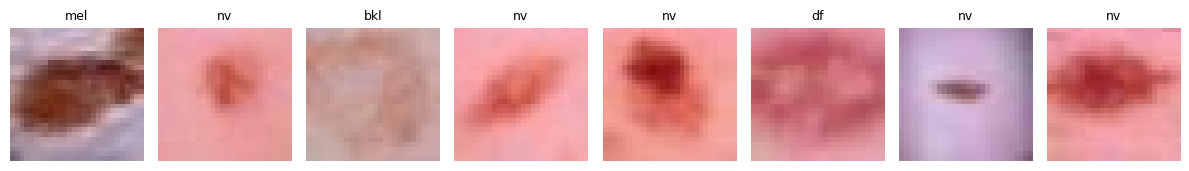

Batch : (128, 3, 28, 28)  min=-1.00  max=1.00


In [2]:
def make_derma(split, transform=None, target_transform=None):
    '''Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli si la version de medmnist ne connaît pas `size`.'''
    kwargs = dict(split=split, root=ROOT, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

def squeeze_target(t):                          # cf. TP 07/08/09 (pas un lambda : pickling)
    return int(np.asarray(t).reshape(-1)[0])

# [0,255] -> float [0,1] -> [-1,1]  (dynamique de la Tanh du générateur)
to_tensor = T_.Compose([
    T_.ToImage(),
    T_.ToDtype(torch.float32, scale=True),
    T_.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

def to01(x):
    '''[-1,1] -> [0,1] pour l'affichage et les métriques.'''
    return (x.clamp(-1, 1) + 1) / 2

train_set = make_derma("train", transform=to_tensor, target_transform=squeeze_target)
test_set  = make_derma("test",  transform=to_tensor, target_transform=squeeze_target)
print(f"Train : {len(train_set)}  |  Test : {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, drop_last=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0)

def show_grid(imgs, titles=None, nrow=8, figsize=None, cmap=None):
    '''Affiche une grille d'images (tenseurs CHW dans [0,1]).'''
    n = len(imgs)
    ncol = nrow
    nrows = (n + ncol - 1) // ncol
    figsize = figsize or (1.5 * ncol, 1.7 * nrows)
    fig, axes = plt.subplots(nrows, ncol, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            img = imgs[i].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
            ax.imshow(img, cmap=cmap)
            if titles is not None and titles[i]:
                ax.set_title(titles[i], fontsize=9)
    plt.tight_layout(); plt.show()

x_batch, y_batch = next(iter(train_loader))
show_grid([to01(x_batch[i]) for i in range(8)],
          titles=[CLASSES_SHORT[int(y_batch[i])] for i in range(8)])
print(f"Batch : {tuple(x_batch.shape)}  min={x_batch.min():.2f}  max={x_batch.max():.2f}")

## Partie III — DCGAN *from scratch*

Architectures symétriques, dimensionnées pour 28×28 (recettes de I.4 appliquées ligne à ligne) :

**Générateur** — du bruit $(100, 1, 1)$ à l'image $(3, 28, 28)$ :

| Couche | Sortie |
|---|---|
| entrée $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ | $(100,\ 1,\ 1)$ |
| `ConvTranspose2d(100→256, k=7)` + BN + ReLU | $(256,\ 7,\ 7)$ |
| `ConvTranspose2d(256→128, k=4, s=2, p=1)` + BN + ReLU | $(128,\ 14,\ 14)$ |
| `ConvTranspose2d(128→64, k=4, s=2, p=1)` + BN + ReLU | $(64,\ 28,\ 28)$ |
| `Conv2d(64→3, k=3, p=1)` + **Tanh** | $(3,\ 28,\ 28)$ |

**Discriminateur** — miroir en convolutions striées, **logit brut** en sortie (la sigmoïde vit dans `BCEWithLogitsLoss`) :

| Couche | Sortie |
|---|---|
| `Conv2d(3→64, k=4, s=2, p=1)` + LeakyReLU(0.2) — **sans BN** | $(64,\ 14,\ 14)$ |
| `Conv2d(64→128, k=4, s=2, p=1)` + BN + LeakyReLU(0.2) | $(128,\ 7,\ 7)$ |
| `Conv2d(128→256, k=3, s=2, p=1)` + BN + LeakyReLU(0.2) | $(256,\ 4,\ 4)$ |
| `Conv2d(256→1, k=4)` → logit | $(1,\ 1,\ 1)$ |

In [3]:
class GeneratorDC(nn.Module):
    '''Générateur DCGAN : z (B, z_dim, 1, 1) -> image (B, 3, 28, 28) dans [-1, 1].'''
    def __init__(self, z_dim=Z_DIM, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 4*base, 7, 1, 0, bias=False),     # -> (256, 7, 7)
            nn.BatchNorm2d(4*base), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(4*base, 2*base, 4, 2, 1, bias=False),    # -> (128, 14, 14)
            nn.BatchNorm2d(2*base), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(2*base, base, 4, 2, 1, bias=False),      # -> (64, 28, 28)
            nn.BatchNorm2d(base), nn.ReLU(inplace=True),
            nn.Conv2d(base, 3, 3, 1, 1),                                # -> (3, 28, 28)
            nn.Tanh(),                                                  # sortie dans [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class DiscriminatorDC(nn.Module):
    '''Discriminateur DCGAN : image (B, in_ch, 28, 28) -> logit (B,).
    Pas de BatchNorm en première couche (recette DCGAN).'''
    def __init__(self, base=64, in_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1),                            # -> (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, 2*base, 4, 2, 1, bias=False),               # -> (128, 7, 7)
            nn.BatchNorm2d(2*base), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(2*base, 4*base, 3, 2, 1, bias=False),             # -> (256, 4, 4)
            nn.BatchNorm2d(4*base), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4*base, 1, 4, 1, 0),                              # -> (1, 1, 1) logit
        )

    def forward(self, x):
        return self.net(x).flatten(1).squeeze(1)


def weights_init_dcgan(m):
    '''Init du papier DCGAN : N(0, 0.02) sur les conv, N(1, 0.02) sur les normalisations.'''
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm2d, nn.InstanceNorm2d)):
        if m.weight is not None:
            nn.init.normal_(m.weight, 1.0, 0.02)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

def n_params(m):
    return sum(p.numel() for p in m.parameters())

G_dc = GeneratorDC().to(device);     G_dc.apply(weights_init_dcgan)
D_dc = DiscriminatorDC().to(device); D_dc.apply(weights_init_dcgan)

z_chk = torch.randn(4, Z_DIM, 1, 1, device=device)
x_chk = G_dc(z_chk)
print(f"G : z {tuple(z_chk.shape)} -> image {tuple(x_chk.shape)}  (min {x_chk.min():.2f}, max {x_chk.max():.2f})")
print(f"D : image -> logits {tuple(D_dc(x_chk).shape)}")
print(f"Paramètres — G : {n_params(G_dc):,}  |  D : {n_params(D_dc):,}")

G : z (4, 100, 1, 1) -> image (4, 3, 28, 28)  (min -0.80, max 0.80)
D : image -> logits (4,)
Paramètres — G : 1,912,387  |  D : 433,985


### La boucle adversariale : les trois points critiques

`train_gan` (cellule suivante) alterne **deux** mises à jour par batch — une pour $D$, une pour $G$ — sans jamais *descendre* une perte unique : on recherche un **équilibre de Nash** (I.4). Trois détails font (ou défont) un GAN — ce sont exactement les mises en garde du slide « boucle d'entraînement » :

1. **`fake.detach()` à l'étape $D$** — on met à jour $D$ sur les images générées, mais sans laisser le gradient de $\mathcal{L}_D$ *remonter* dans $G$. Sans `detach`, le `backward` traverserait tout le graphe $\mathbf{z}\to G\to D$ et $G$ « aiderait » $D$ à le démasquer — l'inverse du but.
2. **Deux `backward()`, deux optimiseurs** (`opt_D`, `opt_G`) : chaque joueur n'optimise que ses propres poids. À l'étape $G$, on **re-passe** `fake` dans $D$ — cette fois *sans* `detach` — pour obtenir le graphe complet $\mathbf{z}\to G\to D$.
3. **Cible $1$ sur les images fausses pour $G$** : c'est la loss **non saturante** de I.3, `bce(D(G(z)), ones)` $= -\log\sigma(a)$, qui envoie un gradient fort *tant que $G$ est mauvais*.

**Hyperparamètres robustes** (recette DCGAN, I.4) : `Adam(lr=2e-4, betas=(0.5, 0.999))` pour les deux réseaux — le $\beta_1$ abaissé réduit l'inertie dans un jeu non stationnaire — et alternance **stricte 1 : 1** (un pas de $D$ pour un pas de $G$).

In [4]:
bce_logits = nn.BCEWithLogitsLoss()

def train_gan(G, D, loader, epochs, cond=False, lr=2e-4, label_real=1.0,
              snap_every=5, tag="GAN"):
    '''Boucle adversariale from scratch (loss non saturante, cf. I.3).

    À chaque itération :
      étape D — monter  log D(x) + log(1 - D(G(z)))   (BCE, cibles label_real / 0) ;
      étape G — monter  log D(G(z))                   (BCE, cible 1 — non saturante).
    Si cond=True, G et D reçoivent aussi le label y (cGAN, Partie IV).
    Retourne l'historique par epoch et des instantanés sur un bruit FIXE z_fix.
    '''
    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    z_fix = torch.randn(64, Z_DIM, 1, 1, device=device)
    y_fix = torch.arange(64, device=device) % NUM_CLASSES
    hist = {"loss_D": [], "loss_G": [], "D_real": [], "D_fake": []}
    snaps, t0 = [], time.time()

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        agg, n_it = np.zeros(4), 0
        for x, y in loader:
            x = x.to(device).contiguous()       # .contiguous() : backward sur MPS (cf. TP 06)
            y = y.to(device)
            z = torch.randn(x.size(0), Z_DIM, 1, 1, device=device)
            fake = G(z, y) if cond else G(z)

            # --- étape D : réel -> label_real, généré (détaché !) -> 0 ---
            opt_D.zero_grad()
            out_real = D(x, y) if cond else D(x)
            out_fake = D(fake.detach(), y) if cond else D(fake.detach())
            loss_D = (bce_logits(out_real, torch.full_like(out_real, label_real))
                      + bce_logits(out_fake, torch.zeros_like(out_fake)))
            loss_D.backward(); opt_D.step()

            # --- étape G : tromper D -> cible 1 (non saturante) ---
            opt_G.zero_grad()
            out_fool = D(fake, y) if cond else D(fake)
            loss_G = bce_logits(out_fool, torch.ones_like(out_fool))
            loss_G.backward(); opt_G.step()

            agg += np.array([loss_D.item(), loss_G.item(),
                             torch.sigmoid(out_real).mean().item(),
                             torch.sigmoid(out_fake).mean().item()])
            n_it += 1

        for k, v in zip(hist, agg / n_it):
            hist[k].append(v)
        if epoch == 1 or epoch % snap_every == 0 or epoch == epochs:
            G.eval()
            with torch.no_grad():
                s = G(z_fix, y_fix) if cond else G(z_fix)
            snaps.append((epoch, s.cpu()))
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"[{tag}] epoch {epoch:3d}/{epochs} | loss_D {hist['loss_D'][-1]:.3f} "
                  f"| loss_G {hist['loss_G'][-1]:.3f} | D(x) {hist['D_real'][-1]:.3f} "
                  f"| D(G(z)) {hist['D_fake'][-1]:.3f} | {time.time()-t0:.0f}s")
    return hist, snaps

hist_dc, snaps_dc = train_gan(G_dc, D_dc, train_loader, EPOCHS_DCGAN, tag="DCGAN")

[DCGAN] epoch   1/40 | loss_D 0.509 | loss_G 3.814 | D(x) 0.858 | D(G(z)) 0.188 | 4s
[DCGAN] epoch   5/40 | loss_D 0.823 | loss_G 2.124 | D(x) 0.708 | D(G(z)) 0.298 | 18s
[DCGAN] epoch  10/40 | loss_D 0.877 | loss_G 1.814 | D(x) 0.685 | D(G(z)) 0.313 | 35s
[DCGAN] epoch  15/40 | loss_D 1.079 | loss_G 1.652 | D(x) 0.630 | D(G(z)) 0.369 | 53s
[DCGAN] epoch  20/40 | loss_D 0.846 | loss_G 2.116 | D(x) 0.704 | D(G(z)) 0.297 | 70s
[DCGAN] epoch  25/40 | loss_D 0.726 | loss_G 2.714 | D(x) 0.751 | D(G(z)) 0.259 | 87s
[DCGAN] epoch  30/40 | loss_D 0.571 | loss_G 3.015 | D(x) 0.784 | D(G(z)) 0.217 | 105s
[DCGAN] epoch  35/40 | loss_D 0.935 | loss_G 2.709 | D(x) 0.734 | D(G(z)) 0.260 | 122s
[DCGAN] epoch  40/40 | loss_D 0.504 | loss_G 2.632 | D(x) 0.796 | D(G(z)) 0.201 | 140s


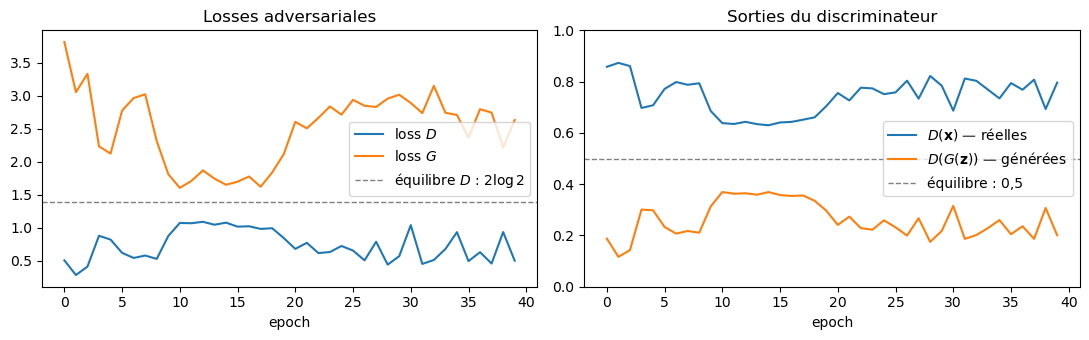

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist_dc["loss_D"], label="loss $D$")
axes[0].plot(hist_dc["loss_G"], label="loss $G$")
axes[0].axhline(2*np.log(2), ls="--", c="gray", lw=1, label=r"équilibre $D$ : $2\log 2$")
axes[0].set_xlabel("epoch"); axes[0].set_title("Losses adversariales"); axes[0].legend()
axes[1].plot(hist_dc["D_real"], label=r"$D(\mathbf{x})$ — réelles")
axes[1].plot(hist_dc["D_fake"], label=r"$D(G(\mathbf{z}))$ — générées")
axes[1].axhline(0.5, ls="--", c="gray", lw=1, label="équilibre : 0,5")
axes[1].set_xlabel("epoch"); axes[1].set_ylim(0, 1)
axes[1].set_title("Sorties du discriminateur"); axes[1].legend()
plt.tight_layout(); plt.show()

# Lecture : pas de descente monotone — c'est un JEU. Les deux sorties doivent
# graviter autour de 0,5 ; D(x) collé à 1 et D(G(z)) à 0 = D a gagné (gradients
# évanescents pour G) ; l'inverse = G domine (vérifier les images !).

**Lecture des courbes — un GAN ne *minimise* pas une courbe.** Contrairement à tous les entraînements précédents, aucune des deux pertes ne doit tendre vers $0$. La théorie de I.2 fournit les **valeurs cibles à l'équilibre** ($p_g = p_{\text{data}}$) :

$$D(\mathbf{x}) \approx D(G(\mathbf{z})) \approx 0{,}5, \qquad \mathcal{L}_D \approx 2\log 2 \approx 1{,}386.$$

Deux signatures d'échec à repérer (I.4) : si $D(\mathbf{x})\!\to\!1$ et $D(G(\mathbf{z}))\!\to\!0$, **$D$ a gagné** — $G$ ne reçoit plus de gradient (gradients évanescents) ; le scénario inverse signale que **$G$ domine**. Dans les deux cas, **les images** restent le juge de dernier recours — d'où les grilles à bruit fixe $\mathbf{z}_{\text{fix}}$ qui suivent.

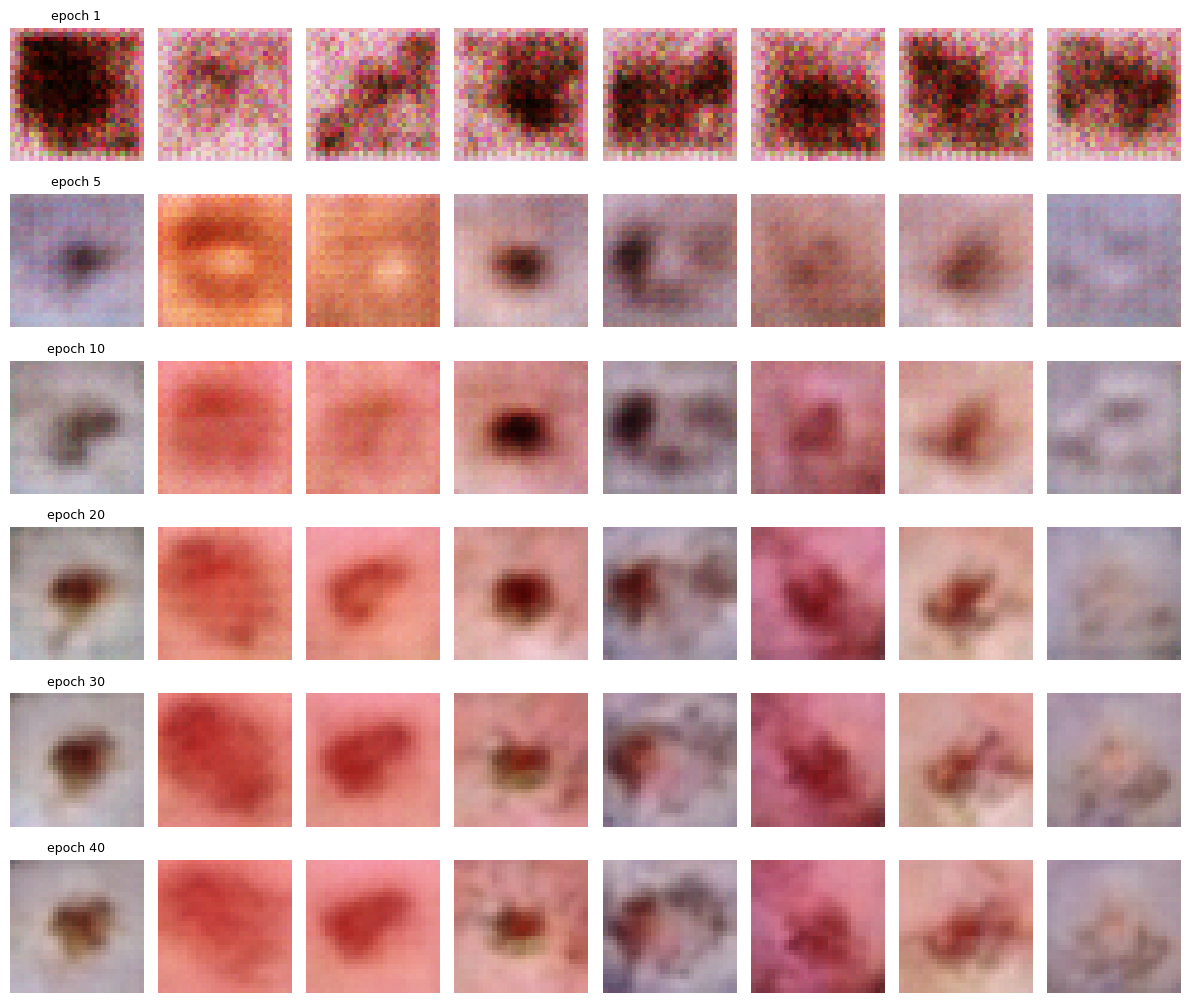

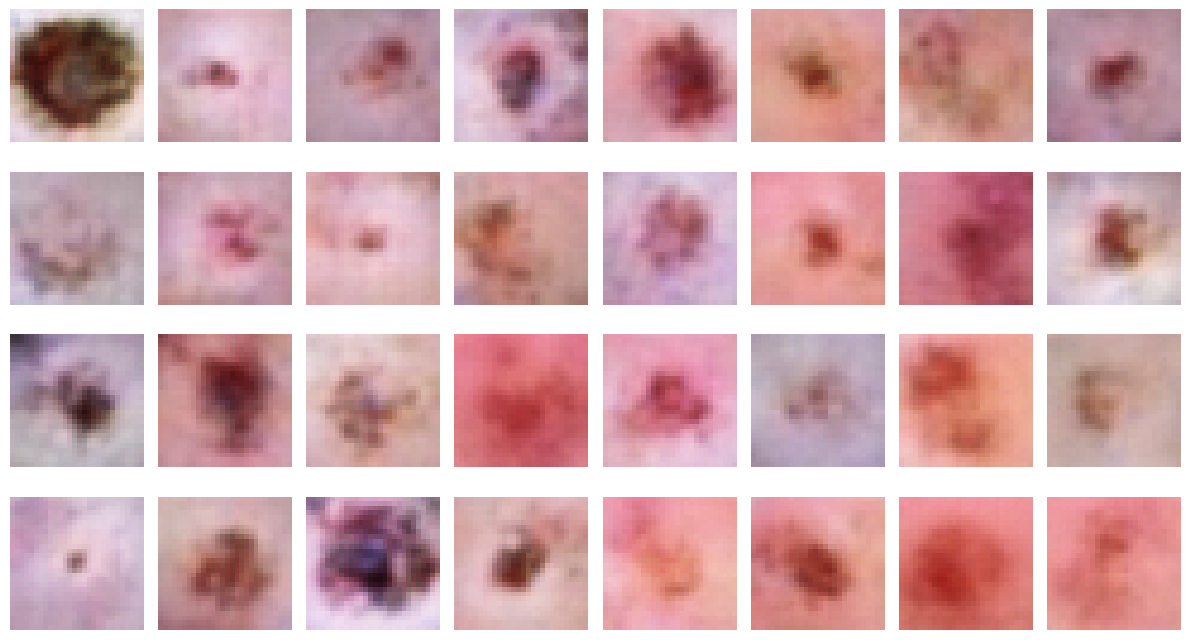

In [6]:
# Évolution des échantillons sur le bruit FIXE z_fix (le vrai juge, cf. I.4)
sel = [s for s in snaps_dc if s[0] in {1, 5, 10, 20, 30, EPOCHS_DCGAN}]
imgs, titles = [], []
for ep, s in sel:
    for j in range(8):
        imgs.append(to01(s[j]))
        titles.append(f"epoch {ep}" if j == 0 else "")
show_grid(imgs, titles=titles, nrow=8)

# Échantillons finaux (z aléatoires, jamais vus pendant le suivi)
G_dc.eval()
with torch.no_grad():
    final = G_dc(torch.randn(32, Z_DIM, 1, 1, device=device)).cpu()
show_grid([to01(im) for im in final], nrow=8)

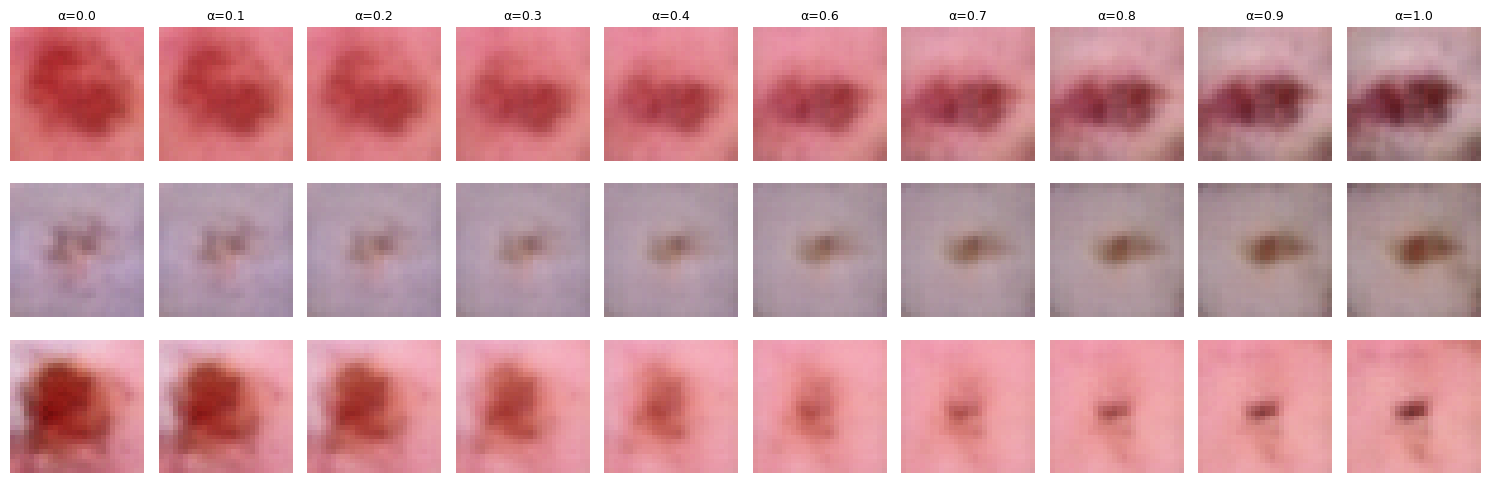

In [7]:
# Interpolation latente : G a-t-il appris une variété continue ?
G_dc.eval()
z_a = torch.randn(3, Z_DIM, 1, 1, device=device)
z_b = torch.randn(3, Z_DIM, 1, 1, device=device)
alphas = torch.linspace(0, 1, 10, device=device)
imgs, titles = [], []
with torch.no_grad():
    for i in range(3):
        for a in alphas:
            z = (1 - a) * z_a[i] + a * z_b[i]          # lerp (slerp : exercice 2)
            imgs.append(to01(G_dc(z.unsqueeze(0))[0].cpu()))
            titles.append(f"α={a.item():.1f}" if i == 0 else "")
show_grid(imgs, titles=titles, nrow=10)

# Transitions douces entre deux lésions : comme pour le VAE (TP 08), l'espace
# latent est interpolable — mais ici AUCUNE régularisation ne l'a imposé,
# la régularité émerge du jeu adversarial lui-même.

## Partie IV — cGAN : génération conditionnelle par classe

On injecte le label $\mathbf{y}$ des deux côtés (cf. I.6), en **réutilisant les corps DCGAN** de la Partie III :

- $G(\mathbf{z}, \mathbf{y})$ : `nn.Embedding(7, 32)` → concaténé à $\mathbf{z}$ → entrée $(100{+}32, 1, 1)$ ;
- $D(\mathbf{x}, \mathbf{y})$ : `nn.Embedding(7, 784)` → carte $1{\times}28{\times}28$ → concaténée comme **4ᵉ canal**.

$D$ ne juge plus « réel ou faux ? » mais « **réel ou faux, *pour cette classe* ?** » — une paire (image *nv* réaliste, label *mel*) doit être rejetée.

In [8]:
class GeneratorCond(nn.Module):
    '''cGAN : label y plongé par nn.Embedding puis concaténé à z (corps DCGAN réutilisé).'''
    def __init__(self, z_dim=Z_DIM, base=64, n_classes=NUM_CLASSES, emb_dim=32):
        super().__init__()
        self.emb  = nn.Embedding(n_classes, emb_dim)
        self.body = GeneratorDC(z_dim=z_dim + emb_dim, base=base)

    def forward(self, z, y):
        e = self.emb(y).unsqueeze(-1).unsqueeze(-1)         # (B, emb_dim, 1, 1)
        return self.body(torch.cat([z, e], dim=1))


class DiscriminatorCond(nn.Module):
    '''cGAN : label projeté en carte spatiale 28×28, concaténée comme 4e canal.'''
    def __init__(self, base=64, n_classes=NUM_CLASSES):
        super().__init__()
        self.emb  = nn.Embedding(n_classes, IMG_SIZE * IMG_SIZE)
        self.body = DiscriminatorDC(base=base, in_ch=4)

    def forward(self, x, y):
        m = self.emb(y).view(-1, 1, IMG_SIZE, IMG_SIZE)
        return self.body(torch.cat([x, m], dim=1))


G_c = GeneratorCond().to(device);     G_c.apply(weights_init_dcgan)
D_c = DiscriminatorCond().to(device); D_c.apply(weights_init_dcgan)

z_chk = torch.randn(4, Z_DIM, 1, 1, device=device)
y_chk = torch.tensor([0, 1, 5, 6], device=device)
print(f"G(z, y) -> {tuple(G_c(z_chk, y_chk).shape)}")
print(f"D(x, y) -> {tuple(D_c(G_c(z_chk, y_chk), y_chk).shape)}")
print(f"Paramètres — G : {n_params(G_c):,}  |  D : {n_params(D_c):,}")

hist_c, snaps_c = train_gan(G_c, D_c, train_loader, EPOCHS_CGAN, cond=True, tag="cGAN")

G(z, y) -> (4, 3, 28, 28)
D(x, y) -> (4,)
Paramètres — G : 2,314,019  |  D : 440,497
[cGAN] epoch   1/40 | loss_D 1.148 | loss_G 2.690 | D(x) 0.638 | D(G(z)) 0.370 | 4s
[cGAN] epoch   5/40 | loss_D 1.023 | loss_G 2.254 | D(x) 0.641 | D(G(z)) 0.354 | 18s
[cGAN] epoch  10/40 | loss_D 1.214 | loss_G 1.071 | D(x) 0.568 | D(G(z)) 0.428 | 36s
[cGAN] epoch  15/40 | loss_D 1.326 | loss_G 1.031 | D(x) 0.537 | D(G(z)) 0.465 | 53s
[cGAN] epoch  20/40 | loss_D 1.395 | loss_G 0.985 | D(x) 0.512 | D(G(z)) 0.488 | 71s
[cGAN] epoch  25/40 | loss_D 1.377 | loss_G 0.982 | D(x) 0.517 | D(G(z)) 0.484 | 89s
[cGAN] epoch  30/40 | loss_D 1.351 | loss_G 0.982 | D(x) 0.522 | D(G(z)) 0.477 | 107s
[cGAN] epoch  35/40 | loss_D 1.366 | loss_G 0.994 | D(x) 0.518 | D(G(z)) 0.479 | 125s
[cGAN] epoch  40/40 | loss_D 1.396 | loss_G 0.854 | D(x) 0.507 | D(G(z)) 0.490 | 142s


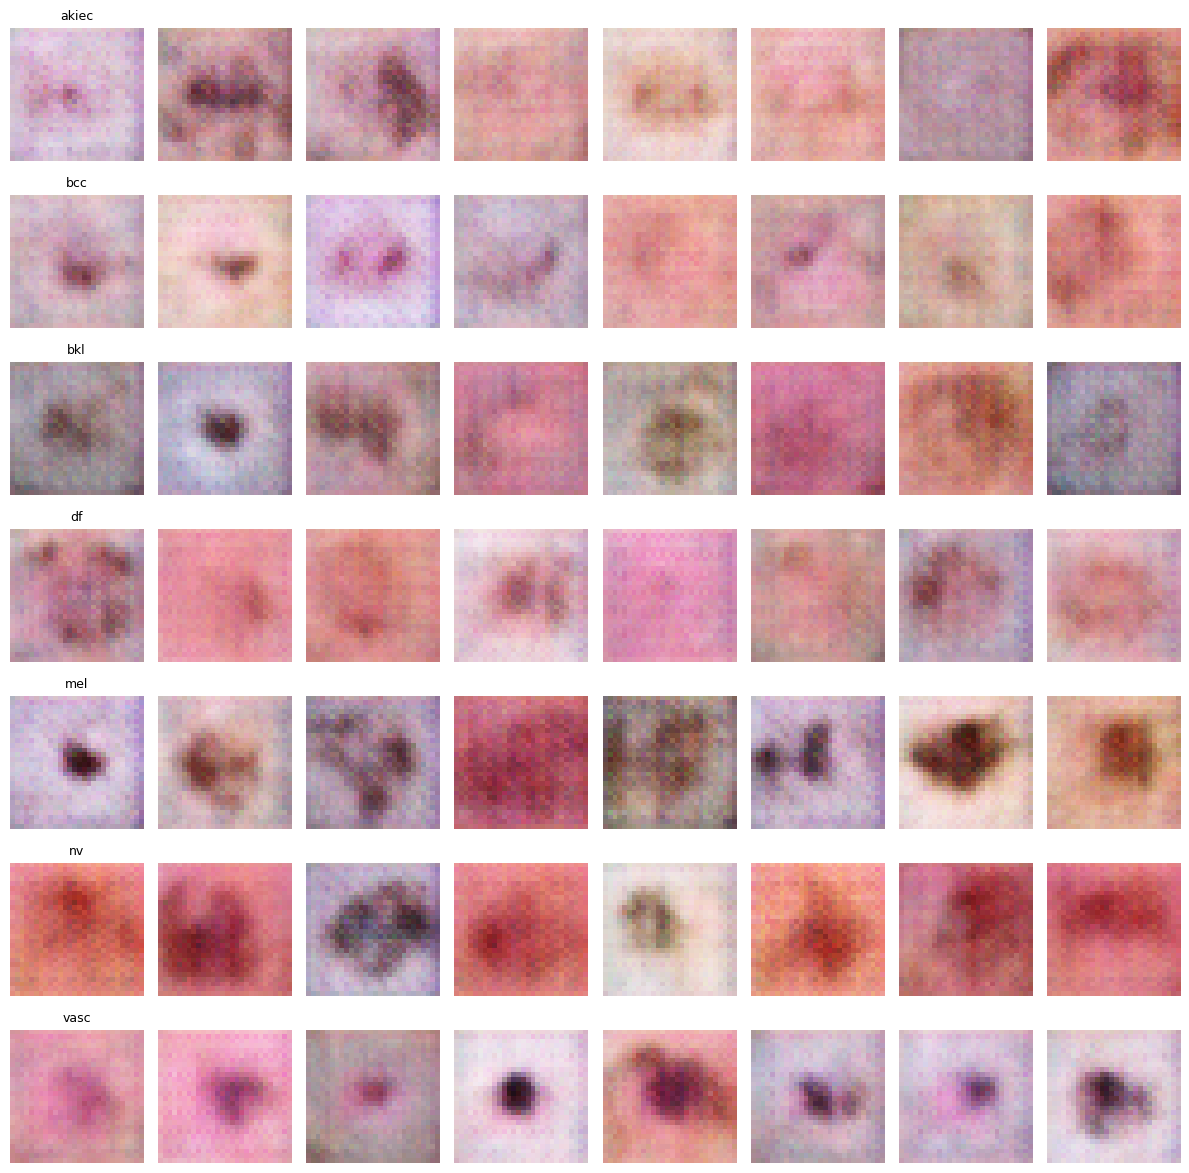

Effectifs train : {'akiec': 228, 'bcc': 359, 'bkl': 769, 'df': 80, 'mel': 779, 'nv': 4693, 'vasc': 99}


In [9]:
# Une ligne par classe : la génération est-elle bien CONTRÔLÉE par y ?
G_c.eval()
imgs, titles = [], []
with torch.no_grad():
    for c in range(NUM_CLASSES):
        z  = torch.randn(8, Z_DIM, 1, 1, device=device)
        y  = torch.full((8,), c, dtype=torch.long, device=device)
        xc = G_c(z, y).cpu()
        for j in range(8):
            imgs.append(to01(xc[j]))
            titles.append(CLASSES_SHORT[c] if j == 0 else "")
show_grid(imgs, titles=titles, nrow=8)

counts = np.bincount([y for _, y in train_set], minlength=NUM_CLASSES)
print("Effectifs train :", dict(zip(CLASSES_SHORT, counts.tolist())))
# Le déséquilibre frappe aussi les génératifs : nv (majoritaire) est nettement
# plus convaincant que df/vasc, appris sur ~100 images. L'exercice 5 mesure si
# ces échantillons synthétiques aident quand même un classifieur.

## Partie V — WGAN-GP : un critique sous contrainte de Lipschitz

Trois changements par rapport au DCGAN (théorie en I.5) :

1. le **critique** remplace le discriminateur : même corps convolutif mais **sans sigmoïde** (score réel non borné) et **sans BatchNorm** — remplacée par `InstanceNorm2d`, car la gradient penalty est définie **par échantillon** ;
2. la loss devient $\mathcal{L}_{\text{critic}} = \mathbb{E}[D(\tilde{\mathbf{x}})] - \mathbb{E}[D(\mathbf{x})] + \lambda\,\mathbb{E}[(\|\nabla_{\hat{\mathbf{x}}} D\|_2 - 1)^2]$ et $\mathcal{L}_G = -\mathbb{E}[D(G(\mathbf{z}))]$ ;
3. **$n_{\text{critic}} = 5$** étapes de critique par étape de générateur, Adam `lr=1e-4, betas=(0.0, 0.9)`.

On vérifie d'abord la gradient penalty **analytiquement** : pour un critique linéaire $f(\mathbf{x}) = \langle \mathbf{w}, \mathbf{x}\rangle$, $\nabla_{\mathbf{x}} f = \mathbf{w}$ partout, donc $\text{GP} = (\|\mathbf{w}\|_2 - 1)^2$ exactement.

In [10]:
class Critic(nn.Module):
    '''Critique WGAN : score réel SANS sigmoïde, InstanceNorm au lieu de BatchNorm
    (la gradient penalty est par échantillon — BatchNorm couplerait le batch).'''
    def __init__(self, base=64, in_ch=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, base, 4, 2, 1),                            # -> (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, 2*base, 4, 2, 1),                           # -> (128, 7, 7)
            nn.InstanceNorm2d(2*base, affine=True), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(2*base, 4*base, 3, 2, 1),                         # -> (256, 4, 4)
            nn.InstanceNorm2d(4*base, affine=True), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(4*base, 1, 4, 1, 0),                              # -> score (1, 1, 1)
        )

    def forward(self, x):
        return self.net(x).flatten(1).squeeze(1)


def gradient_penalty(critic, real, fake):
    '''GP de Gulrajani et al. (2017) : E[(||∇_x̂ D(x̂)||₂ − 1)²] sur x̂ interpolé.
    create_graph=True : le gradient fait partie du graphe -> double backward.'''
    eps   = torch.rand(real.size(0), 1, 1, 1, device=real.device)
    x_hat = (eps * real + (1 - eps) * fake).requires_grad_(True)
    grad  = torch.autograd.grad(outputs=critic(x_hat).sum(), inputs=x_hat,
                                create_graph=True)[0]
    return ((grad.flatten(1).norm(2, dim=1) - 1) ** 2).mean()


# --- Vérification analytique sur un critique linéaire f(x) = <w, x> ---
class _LinearCritic(nn.Module):
    def __init__(self, w):
        super().__init__()
        self.w = nn.Parameter(w)
    def forward(self, x):
        return (x * self.w).flatten(1).sum(1)

w_lin  = torch.randn(3, IMG_SIZE, IMG_SIZE)
w_lin *= 1.3 / w_lin.norm()          # ||w|| = 1,3 -> GP attendue : (1,3-1)² = 0,09 (cf. I.5)
gp_num = gradient_penalty(_LinearCritic(w_lin),
                          torch.randn(16, 3, IMG_SIZE, IMG_SIZE),
                          torch.randn(16, 3, IMG_SIZE, IMG_SIZE))
gp_ana = (w_lin.norm() - 1) ** 2
print(f"GP numérique  : {gp_num.item():.6f}")
print(f"GP analytique : {gp_ana.item():.6f}   (||w|| - 1)²")
assert torch.isclose(gp_num, gp_ana, rtol=1e-4), "gradient_penalty incorrecte !"
print("✓ gradient_penalty vérifiée")

GP numérique  : 0.090000
GP analytique : 0.090000   (||w|| - 1)²
✓ gradient_penalty vérifiée


In [11]:
N_CRITIC, LAMBDA_GP = 5, 10.0

G_w = GeneratorDC().to(device); G_w.apply(weights_init_dcgan)
C_w = Critic().to(device);      C_w.apply(weights_init_dcgan)
opt_Gw = torch.optim.Adam(G_w.parameters(), lr=1e-4, betas=(0.0, 0.9))
opt_Cw = torch.optim.Adam(C_w.parameters(), lr=1e-4, betas=(0.0, 0.9))

hist_w, t0 = {"W_est": [], "gp": []}, time.time()
for epoch in range(1, EPOCHS_WGAN + 1):
    G_w.train(); C_w.train()
    w_sum = gp_sum = 0.0
    n_it = 0
    for i, (x, _) in enumerate(train_loader):
        x = x.to(device).contiguous()
        z = torch.randn(x.size(0), Z_DIM, 1, 1, device=device)
        fake = G_w(z).detach()

        # --- étape critique (chaque batch) ---
        d_real, d_fake = C_w(x).mean(), C_w(fake).mean()
        gp = gradient_penalty(C_w, x, fake)
        loss_C = d_fake - d_real + LAMBDA_GP * gp
        opt_Cw.zero_grad(); loss_C.backward(); opt_Cw.step()
        w_sum += (d_real - d_fake).item(); gp_sum += gp.item(); n_it += 1

        # --- étape générateur : 1 batch sur N_CRITIC ---
        if (i + 1) % N_CRITIC == 0:
            z = torch.randn(x.size(0), Z_DIM, 1, 1, device=device)
            loss_G = -C_w(G_w(z)).mean()
            opt_Gw.zero_grad(); loss_G.backward(); opt_Gw.step()

    hist_w["W_est"].append(w_sum / n_it); hist_w["gp"].append(gp_sum / n_it)
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS_WGAN:
        print(f"[WGAN-GP] epoch {epoch:3d}/{EPOCHS_WGAN} | Ŵ ≈ {w_sum/n_it:7.3f} "
              f"| GP {gp_sum/n_it:.3f} | {time.time()-t0:.0f}s")

[WGAN-GP] epoch   1/25 | Ŵ ≈   1.135 | GP 2.892 | 4s
[WGAN-GP] epoch   5/25 | Ŵ ≈   4.967 | GP 0.072 | 18s
[WGAN-GP] epoch  10/25 | Ŵ ≈   3.654 | GP 0.053 | 35s
[WGAN-GP] epoch  15/25 | Ŵ ≈   4.362 | GP 0.051 | 53s
[WGAN-GP] epoch  20/25 | Ŵ ≈   2.908 | GP 0.028 | 70s
[WGAN-GP] epoch  25/25 | Ŵ ≈   2.937 | GP 0.030 | 88s


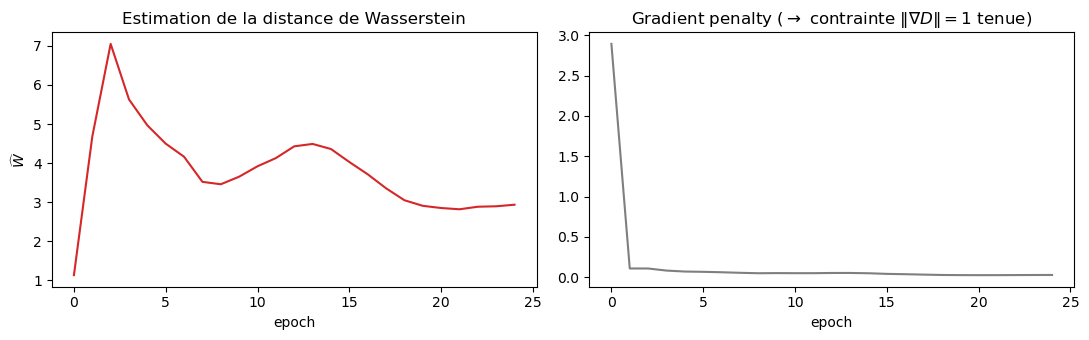

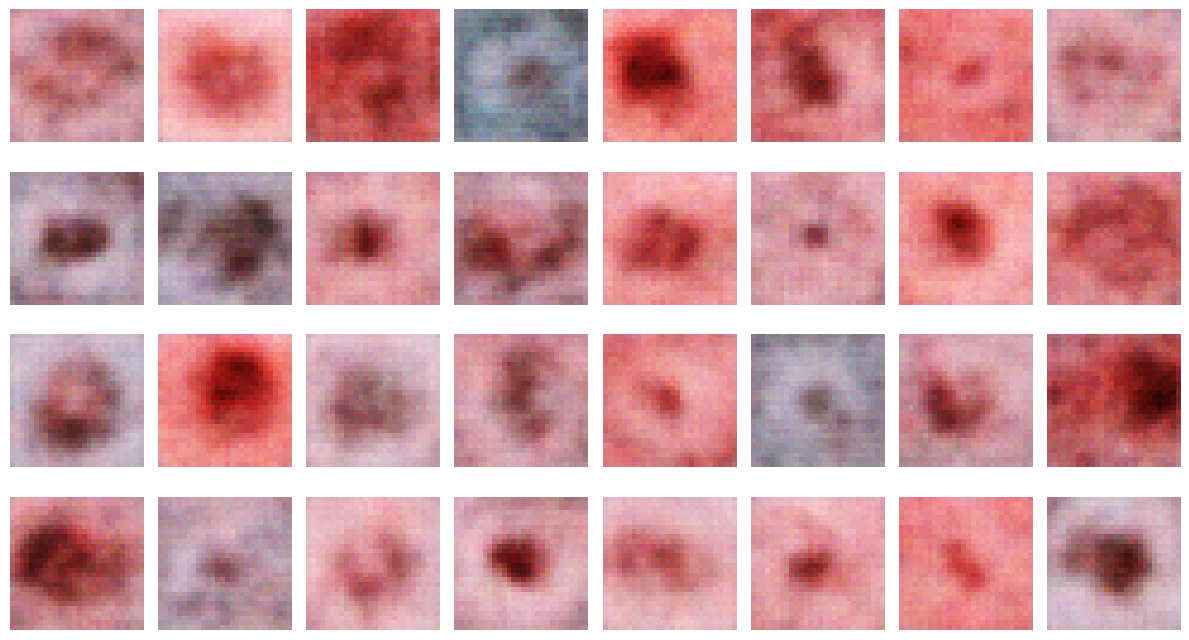

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(hist_w["W_est"], color="tab:red")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel(r"$\widehat{W}$")
axes[0].set_title("Estimation de la distance de Wasserstein")
axes[1].plot(hist_w["gp"], color="tab:gray")
axes[1].set_xlabel("epoch"); axes[1].set_title(r"Gradient penalty ($\to$ contrainte $\|\nabla D\|=1$ tenue)")
plt.tight_layout(); plt.show()

G_w.eval()
with torch.no_grad():
    sw = G_w(torch.randn(32, Z_DIM, 1, 1, device=device)).cpu()
show_grid([to01(im) for im in sw], nrow=8)

# Lecture : Ŵ commence par MONTER — le critique apprend à séparer, et son
# estimation de W est une borne inférieure (duale) — puis redescend : p_g se
# rapproche de p_data au sens de Wasserstein. Contrairement aux courbes DCGAN,
# cette courbe est un vrai thermomètre (ablations λ et n_critic : exercice 4).

## Partie VI — Pix2Pix : traduction d'image (colorisation)

Tâche : **luminance → couleur**. Chaque image RGB fournit gratuitement sa paire d'entraînement via la luminance (Rec. 601) :

$$Y = 0{,}299\,R + 0{,}587\,G + 0{,}114\,B$$

C'est le schéma général de Pix2Pix : dès qu'une **dégradation calculable** produit l'entrée (niveaux de gris, basse résolution, contours…), on a un dataset apparié sans annotation. En dermatoscopie, ce *re-rendu couleur* normalisé a un intérêt pratique : la couleur est **diagnostique** (cf. la prudence sur `ColorJitter` aux TP 03/04).

Architecture (cf. I.6) :
- $G$ = **U-Net** 28→14→7→4→7→14→28 avec skip connections — la structure (contours de la lésion) traverse directement, le réseau n'apprend que le *rendu* ;
- $D$ = **PatchGAN** sur la paire concaténée (gris ⊕ couleur, 4 canaux) → carte de logits $7{\times}7$ ; champ réceptif de chaque logit : **18×18 pixels** (il juge des *patchs*, pas l'image entière) ;
- $\mathcal{L}_G = \mathcal{L}_{\text{adv}} + \lambda\,\mathcal{L}_{L_1}$, $\lambda = 100$ — la $L_1$ garantit la fidélité, l'adversarial la netteté (rôle de $\lambda$ : exercice 6).

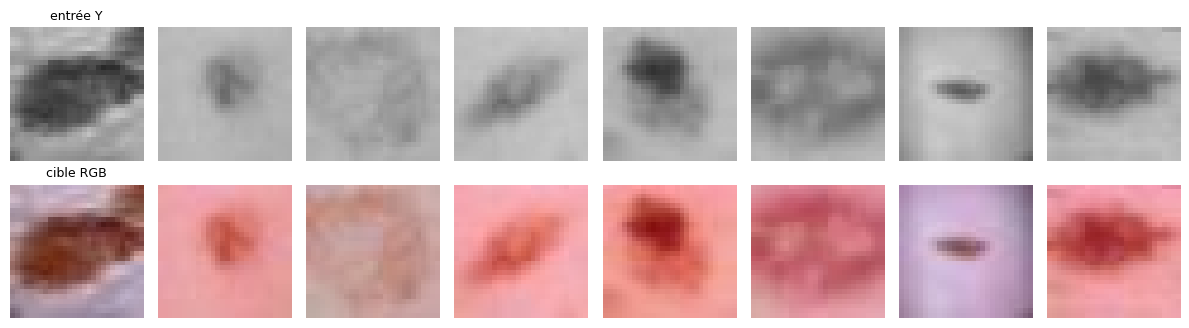

In [13]:
LUMA = torch.tensor([0.299, 0.587, 0.114])

def to_gray(x):
    '''RGB [-1,1] (B,3,H,W) -> luminance [-1,1] (B,1,H,W), Rec. 601.'''
    g = (to01(x) * LUMA.to(x.device).view(1, 3, 1, 1)).sum(dim=1, keepdim=True)
    return g * 2 - 1

x_demo = x_batch[:8].to(device)
g_demo = to_gray(x_demo)
imgs, titles = [], []
for j in range(8):
    imgs.append(to01(g_demo[j].expand(3, -1, -1).cpu())); titles.append("entrée Y" if j == 0 else "")
for j in range(8):
    imgs.append(to01(x_demo[j].cpu())); titles.append("cible RGB" if j == 0 else "")
show_grid(imgs, titles=titles, nrow=8)

In [14]:
class UNetColorize(nn.Module):
    '''U-Net 28×28 pour Pix2Pix : encodeur 28->14->7->4, décodeur symétrique
    avec skip connections par concaténation (cf. TP 07).'''
    def __init__(self, base=64):
        super().__init__()
        def down(ci, co, k=4, norm=True):
            layers = [nn.Conv2d(ci, co, k, 2, 1, bias=not norm)]
            if norm:
                layers.append(nn.BatchNorm2d(co))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return nn.Sequential(*layers)
        def up(ci, co, k=4):
            return nn.Sequential(nn.ConvTranspose2d(ci, co, k, 2, 1, bias=False),
                                 nn.BatchNorm2d(co), nn.ReLU(inplace=True))
        self.e1 = down(1, base, norm=False)            # 28 -> 14
        self.e2 = down(base, 2*base)                   # 14 -> 7
        self.e3 = down(2*base, 4*base, k=3)            # 7  -> 4
        self.d1 = up(4*base, 2*base, k=3)              # 4  -> 7
        self.d2 = up(4*base, base)                     # 7  -> 14   (entrée : d1 ⊕ e2)
        self.d3 = up(2*base, base)                     # 14 -> 28   (entrée : d2 ⊕ e1)
        self.out = nn.Sequential(nn.Conv2d(base, 3, 3, 1, 1), nn.Tanh())

    def forward(self, g):
        e1 = self.e1(g); e2 = self.e2(e1); e3 = self.e3(e2)
        d1 = self.d1(e3)
        d2 = self.d2(torch.cat([d1, e2], dim=1))
        d3 = self.d3(torch.cat([d2, e1], dim=1))
        return self.out(d3)


class PatchGAN(nn.Module):
    '''Discriminateur par patchs : paire (gris ⊕ couleur, 4 canaux) -> carte de
    logits 7×7. Chaque logit juge un patch 18×18 (champ réceptif), pas l'image.'''
    def __init__(self, base=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(4, base, 4, 2, 1),                                # -> (64, 14, 14)
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base, 2*base, 4, 2, 1, bias=False),               # -> (128, 7, 7)
            nn.BatchNorm2d(2*base), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(2*base, 1, 3, 1, 1),                              # -> carte (1, 7, 7)
        )

    def forward(self, gray, rgb):
        return self.net(torch.cat([gray, rgb], dim=1))


G_p2p = UNetColorize().to(device); G_p2p.apply(weights_init_dcgan)
D_p2p = PatchGAN().to(device);     D_p2p.apply(weights_init_dcgan)
out_chk = G_p2p(g_demo)
print(f"G : gris {tuple(g_demo.shape)} -> RGB {tuple(out_chk.shape)}")
print(f"D : paire -> carte de logits {tuple(D_p2p(g_demo, out_chk).shape)}")
print(f"Paramètres — G : {n_params(G_p2p):,}  |  D (PatchGAN) : {n_params(D_p2p):,}")

G : gris (8, 1, 28, 28) -> RGB (8, 3, 28, 28)
D : paire -> carte de logits (8, 1, 7, 7)
Paramètres — G : 1,118,211  |  D (PatchGAN) : 136,641


[Pix2Pix] epoch  1/10 | loss_D 1.295 | adv 0.767 | L1 0.1388 | 3s
[Pix2Pix] epoch  2/10 | loss_D 1.220 | adv 0.832 | L1 0.0919 | 5s
[Pix2Pix] epoch  3/10 | loss_D 1.116 | adv 0.942 | L1 0.0838 | 8s
[Pix2Pix] epoch  4/10 | loss_D 1.122 | adv 0.989 | L1 0.0820 | 10s
[Pix2Pix] epoch  5/10 | loss_D 1.104 | adv 0.999 | L1 0.0796 | 13s
[Pix2Pix] epoch  6/10 | loss_D 1.105 | adv 1.015 | L1 0.0786 | 15s
[Pix2Pix] epoch  7/10 | loss_D 1.107 | adv 1.045 | L1 0.0777 | 18s
[Pix2Pix] epoch  8/10 | loss_D 1.075 | adv 1.080 | L1 0.0764 | 20s
[Pix2Pix] epoch  9/10 | loss_D 1.073 | adv 1.153 | L1 0.0773 | 23s
[Pix2Pix] epoch 10/10 | loss_D 1.030 | adv 1.199 | L1 0.0758 | 25s


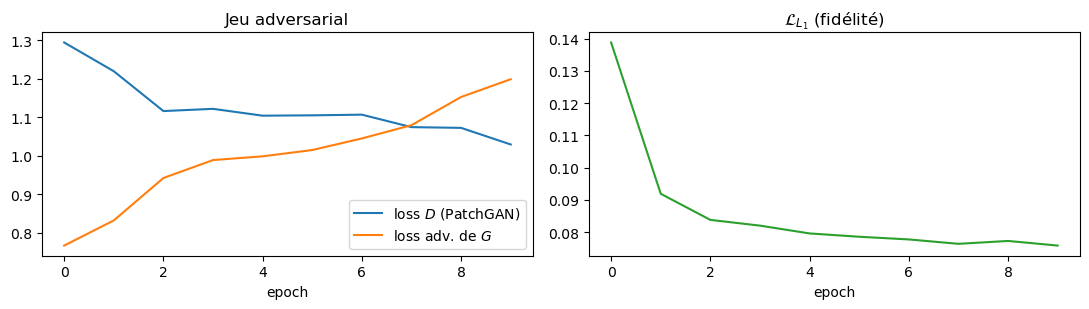

In [15]:
LAMBDA_L1 = 100.0

opt_Gp = torch.optim.Adam(G_p2p.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_Dp = torch.optim.Adam(D_p2p.parameters(), lr=2e-4, betas=(0.5, 0.999))

hist_p, t0 = {"loss_D": [], "loss_adv": [], "loss_L1": []}, time.time()
for epoch in range(1, EPOCHS_P2P + 1):
    G_p2p.train(); D_p2p.train()
    agg, n_it = np.zeros(3), 0
    for x, _ in train_loader:
        x = x.to(device).contiguous()
        g = to_gray(x)
        fake = G_p2p(g)

        # --- D : paire (gris, vraie couleur) -> 1 ; (gris, colorisée) -> 0 ---
        opt_Dp.zero_grad()
        out_r = D_p2p(g, x)
        out_f = D_p2p(g, fake.detach())
        loss_D = (bce_logits(out_r, torch.ones_like(out_r))
                  + bce_logits(out_f, torch.zeros_like(out_f)))
        loss_D.backward(); opt_Dp.step()

        # --- G : adversarial (patchs -> 1) + λ·L1 (fidélité pixel) ---
        opt_Gp.zero_grad()
        out      = D_p2p(g, fake)
        loss_adv = bce_logits(out, torch.ones_like(out))
        loss_l1  = F.l1_loss(fake, x)
        (loss_adv + LAMBDA_L1 * loss_l1).backward(); opt_Gp.step()

        agg += np.array([loss_D.item(), loss_adv.item(), loss_l1.item()]); n_it += 1

    for k, v in zip(hist_p, agg / n_it):
        hist_p[k].append(v)
    print(f"[Pix2Pix] epoch {epoch:2d}/{EPOCHS_P2P} | loss_D {agg[0]/n_it:.3f} "
          f"| adv {agg[1]/n_it:.3f} | L1 {agg[2]/n_it:.4f} | {time.time()-t0:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].plot(hist_p["loss_D"], label="loss $D$ (PatchGAN)")
axes[0].plot(hist_p["loss_adv"], label="loss adv. de $G$")
axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].set_title("Jeu adversarial")
axes[1].plot(hist_p["loss_L1"], color="tab:green")
axes[1].set_xlabel("epoch"); axes[1].set_title(r"$\mathcal{L}_{L_1}$ (fidélité)")
plt.tight_layout(); plt.show()

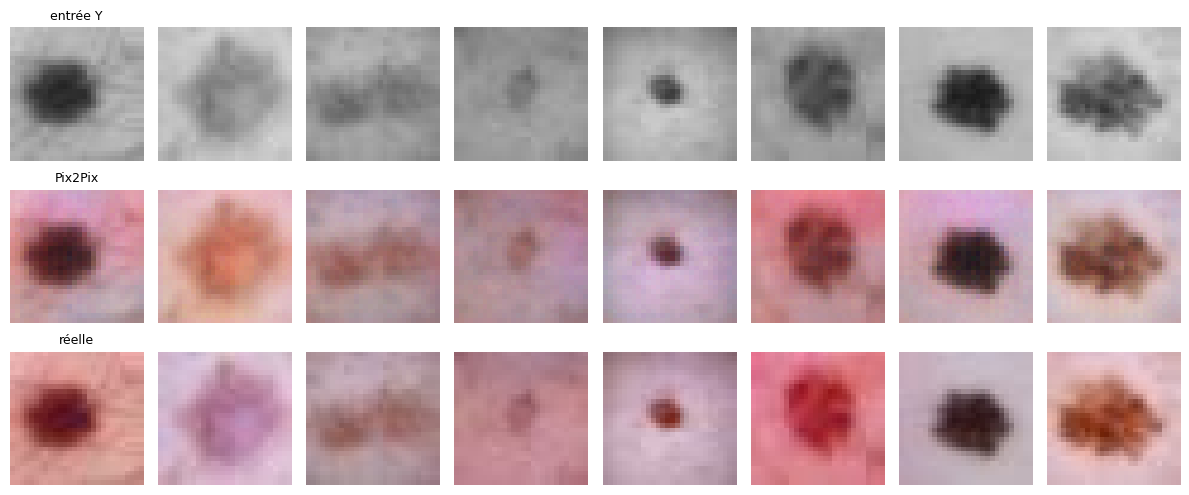

L1 test : 0.0809 (pixels dans [-1,1])


In [16]:
# Colorisation sur le jeu de TEST (jamais vu)
x_test8 = next(iter(test_loader))[0][:8].to(device).contiguous()
g_test8 = to_gray(x_test8)
G_p2p.eval()
with torch.no_grad():
    fake8 = G_p2p(g_test8)

imgs, titles = [], []
for batch, lab in [(g_test8.expand(-1, 3, -1, -1), "entrée Y"),
                   (fake8, "Pix2Pix"), (x_test8, "réelle")]:
    for j in range(8):
        imgs.append(to01(batch[j].cpu()))
        titles.append(lab if j == 0 else "")
show_grid(imgs, titles=titles, nrow=8)

# L1 moyenne sur tout le test
tot, n = 0.0, 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device).contiguous()
        tot += F.l1_loss(G_p2p(to_gray(x)), x, reduction="sum").item()
        n   += x.numel()
print(f"L1 test : {tot/n:.4f} (pixels dans [-1,1])")

## Partie VII — SRGAN : super-résolution ×2

Paires construites par **dégradation bicubique** : HR $28{\times}28$ → LR $14{\times}14$. Entraînement en **deux temps**, comme dans le papier :

1. **SRResNet** — le générateur seul, loss $L_1$ pixel : il maximise la fidélité (≈ PSNR). Le réseau apprend le **résidu global** $G(\mathbf{x}_{\text{LR}}) = \text{bicubique}(\mathbf{x}_{\text{LR}}) + f_\theta(\mathbf{x}_{\text{LR}})$ (à la VDSR) : il **part de la baseline bicubique** et n'apprend que ce qu'elle rate — hautes fréquences et textures ;
2. **SRGAN** — on repart du SRResNet pré-entraîné et on optimise $\mathcal{L}_G = \mathcal{L}_{\text{content}} + 10^{-3}\,\mathcal{L}_{\text{adv}}$, où $\mathcal{L}_{\text{content}}$ est la **loss perceptuelle** dans l'espace de features du **ResNet18 fine-tuné au TP 04** (gelé, tronqué après `layer1` : textures et contours) — plus un petit ancrage $L_1$ ($10^{-2}$) pour stabiliser les couleurs.

Métriques (sur $[0,1]$) :

$$\mathrm{PSNR} = 10 \log_{10}\frac{1}{\mathrm{MSE}} \ \text{(dB)} \qquad \text{et SSIM (structure locale, } \in [-1, 1]\text{)}$$

Attendu (compromis **perception–distorsion**, cf. I.6) : SRGAN peut perdre quelques dixièmes de dB de PSNR face au SRResNet tout en restituant des textures plus crédibles. À 28×28 le gain visuel reste modeste — l'exercice 7 passe en ×4, où l'écart devient flagrant.

In [17]:
SCALE = 2

def make_lr(x):
    '''HR [-1,1] -> LR (dégradation bicubique antialiasée, facteur 1/SCALE).'''
    return F.interpolate(x, scale_factor=1/SCALE, mode="bicubic", antialias=True).clamp(-1, 1)

def psnr(a, b):
    '''PSNR en dB entre deux batches d'images [-1,1] (calcul sur [0,1]).'''
    mse = F.mse_loss(to01(a), to01(b))
    return float(10 * torch.log10(1.0 / mse))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except ImportError:
    HAS_SKIMAGE = False
    print("scikit-image absent : SSIM ignoré (pip install scikit-image)")

def ssim_batch(a, b):
    '''SSIM moyen d'un batch (skimage, images [0,1] HWC) — NaN si indisponible.'''
    if not HAS_SKIMAGE:
        return float("nan")
    vals = [ssim_fn(to01(ai).permute(1, 2, 0).numpy(),
                    to01(bi).permute(1, 2, 0).numpy(),
                    channel_axis=2, data_range=1.0)
            for ai, bi in zip(a.cpu(), b.cpu())]
    return float(np.mean(vals))

x_val = next(iter(test_loader))[0].to(device).contiguous()
lr_val  = make_lr(x_val)
bic_val = F.interpolate(lr_val, scale_factor=SCALE, mode="bicubic").clamp(-1, 1)
print(f"HR {tuple(x_val.shape[-2:])} -> LR {tuple(lr_val.shape[-2:])}")
print(f"Référence bicubique : PSNR {psnr(bic_val, x_val):.2f} dB | SSIM {ssim_batch(bic_val, x_val):.3f}")

HR (28, 28) -> LR (14, 14)
Référence bicubique : PSNR 37.23 dB | SSIM 0.972


In [18]:
class ResBlock(nn.Module):
    '''Bloc résiduel SRGAN : Conv-BN-PReLU-Conv-BN + identité (pas d'activation finale).'''
    def __init__(self, ch=64):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False), nn.BatchNorm2d(ch), nn.PReLU(),
            nn.Conv2d(ch, ch, 3, 1, 1, bias=False), nn.BatchNorm2d(ch))

    def forward(self, x):
        return x + self.body(x)


class SRResNet(nn.Module):
    '''Générateur SRGAN ×SCALE : tête conv, blocs résiduels, skip global, puis
    sub-pixel convolution (PixelShuffle). Apprentissage RÉSIDUEL global : le
    réseau prédit la CORRECTION à ajouter à l'upsampling bicubique — il part
    donc de la baseline et ne peut que l'améliorer (cf. PSNR de l'epoch 1).'''
    def __init__(self, ch=64, n_blocks=4):
        super().__init__()
        self.head = nn.Sequential(nn.Conv2d(3, ch, 3, 1, 1), nn.PReLU())
        self.body = nn.Sequential(*[ResBlock(ch) for _ in range(n_blocks)],
                                  nn.Conv2d(ch, ch, 3, 1, 1, bias=False), nn.BatchNorm2d(ch))
        self.up   = nn.Sequential(nn.Conv2d(ch, ch * SCALE**2, 3, 1, 1),
                                  nn.PixelShuffle(SCALE), nn.PReLU())
        self.tail = nn.Conv2d(ch, 3, 3, 1, 1)        # pas de Tanh : la sortie est un résidu

    def forward(self, lr):
        base = F.interpolate(lr, scale_factor=SCALE, mode="bicubic")
        h = self.head(lr)
        h = h + self.body(h)               # skip global
        return base + self.tail(self.up(h))


# --- Extracteur perceptuel : le ResNet18 fine-tuné au TP 04, gelé ---
from torchvision.models import resnet18

TP04_CKPT     = Path("../module_2/checkpoints/resnet18_dermamnist_best.pt")
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)

def build_feature_extractor():
    '''φ pour la loss perceptuelle : ResNet18 fine-tuné TP 04 (DermaMNIST) si son
    checkpoint existe, sinon ResNet18 ImageNet, sinon init aléatoire (dégradé).
    Tronqué après layer1 : cartes (64, 7, 7) à 28×28 — textures et contours.'''
    net = resnet18(weights=None)
    if TP04_CKPT.exists():
        sd = torch.load(TP04_CKPT, map_location="cpu", weights_only=False)["model_state_dict"]
        net.fc = nn.Linear(net.fc.in_features, NUM_CLASSES)
        net.load_state_dict(sd)
        src = "ResNet18 fine-tuné TP 04 (DermaMNIST)"
    else:
        try:
            from torchvision.models import ResNet18_Weights
            net = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
            src = "ResNet18 ImageNet (torchvision) — checkpoint TP 04 introuvable"
        except Exception:
            src = "ResNet18 NON pré-entraîné (repli hors ligne, loss perceptuelle dégradée)"
    feat = nn.Sequential(net.conv1, net.bn1, net.relu, net.maxpool, net.layer1)
    feat.to(device).eval().requires_grad_(False)
    print(f"Extracteur perceptuel φ : {src}")
    return feat

feat_net = build_feature_extractor()

def perceptual_loss(sr, hr):
    '''MSE dans l'espace de features φ (entrées renormalisées ImageNet, cf. TP 04).'''
    def prep(x):
        return (to01(x) - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)
    return F.mse_loss(feat_net(prep(sr)), feat_net(prep(hr)))

G_sr = SRResNet().to(device)
print(f"SRResNet : LR {tuple(lr_val.shape[1:])} -> SR {tuple(G_sr(lr_val[:2]).shape[1:])} "
      f"| paramètres : {n_params(G_sr):,}")

Extracteur perceptuel φ : ResNet18 fine-tuné TP 04 (DermaMNIST)
SRResNet : LR (3, 14, 14) -> SR (3, 28, 28) | paramètres : 484,169


In [19]:
# --- Étape 1 : pré-entraînement SRResNet en L1 pure (fidélité maximale) ---
opt_sr = torch.optim.Adam(G_sr.parameters(), lr=1e-4)
t0 = time.time()
for epoch in range(1, EPOCHS_SR_PRE + 1):
    G_sr.train()
    tot, n_it = 0.0, 0
    for x, _ in train_loader:
        x  = x.to(device).contiguous()
        sr = G_sr(make_lr(x))
        loss = F.l1_loss(sr, x)
        opt_sr.zero_grad(); loss.backward(); opt_sr.step()
        tot += loss.item(); n_it += 1
    G_sr.eval()
    with torch.no_grad():
        p = psnr(G_sr(lr_val), x_val)
    print(f"[SRResNet-L1] epoch {epoch}/{EPOCHS_SR_PRE} | L1 {tot/n_it:.4f} "
          f"| PSNR val {p:.2f} dB | {time.time()-t0:.0f}s")

[SRResNet-L1] epoch 1/15 | L1 0.0464 | PSNR val 35.71 dB | 2s
[SRResNet-L1] epoch 2/15 | L1 0.0209 | PSNR val 36.64 dB | 4s
[SRResNet-L1] epoch 3/15 | L1 0.0188 | PSNR val 37.15 dB | 6s
[SRResNet-L1] epoch 4/15 | L1 0.0179 | PSNR val 37.38 dB | 7s
[SRResNet-L1] epoch 5/15 | L1 0.0172 | PSNR val 37.73 dB | 9s
[SRResNet-L1] epoch 6/15 | L1 0.0167 | PSNR val 37.99 dB | 11s
[SRResNet-L1] epoch 7/15 | L1 0.0163 | PSNR val 37.88 dB | 13s
[SRResNet-L1] epoch 8/15 | L1 0.0160 | PSNR val 38.18 dB | 15s
[SRResNet-L1] epoch 9/15 | L1 0.0157 | PSNR val 38.31 dB | 16s
[SRResNet-L1] epoch 10/15 | L1 0.0154 | PSNR val 38.48 dB | 18s
[SRResNet-L1] epoch 11/15 | L1 0.0152 | PSNR val 38.48 dB | 20s
[SRResNet-L1] epoch 12/15 | L1 0.0152 | PSNR val 38.57 dB | 22s
[SRResNet-L1] epoch 13/15 | L1 0.0149 | PSNR val 38.67 dB | 24s
[SRResNet-L1] epoch 14/15 | L1 0.0149 | PSNR val 38.65 dB | 25s
[SRResNet-L1] epoch 15/15 | L1 0.0148 | PSNR val 38.71 dB | 27s


In [20]:
# --- Étape 2 : SRGAN — repartir du SRResNet et ajouter perceptuel + adversarial ---
G_srgan = copy.deepcopy(G_sr)                      # init depuis le pré-entraîné (papier)
D_sr    = DiscriminatorDC().to(device); D_sr.apply(weights_init_dcgan)
opt_Gs  = torch.optim.Adam(G_srgan.parameters(), lr=1e-4)
opt_Ds  = torch.optim.Adam(D_sr.parameters(), lr=1e-4)

t0 = time.time()
for epoch in range(1, EPOCHS_SRGAN + 1):
    G_srgan.train(); D_sr.train()
    agg, n_it = np.zeros(2), 0
    for x, _ in train_loader:
        x  = x.to(device).contiguous()
        sr = G_srgan(make_lr(x))

        # --- D : HR réelle -> 1, SR générée -> 0 ---
        opt_Ds.zero_grad()
        out_r, out_f = D_sr(x), D_sr(sr.detach())
        loss_D = (bce_logits(out_r, torch.ones_like(out_r))
                  + bce_logits(out_f, torch.zeros_like(out_f)))
        loss_D.backward(); opt_Ds.step()

        # --- G : contenu perceptuel + 1e-3 adversarial + petit ancrage L1 ---
        opt_Gs.zero_grad()
        out_g        = D_sr(sr)
        loss_content = perceptual_loss(sr, x)
        loss_adv     = bce_logits(out_g, torch.ones_like(out_g))
        (loss_content + 1e-3 * loss_adv + 1e-2 * F.l1_loss(sr, x)).backward()
        opt_Gs.step()

        agg += np.array([loss_content.item(), loss_adv.item()]); n_it += 1

    G_srgan.eval()
    with torch.no_grad():
        p = psnr(G_srgan(lr_val), x_val)
    print(f"[SRGAN] epoch {epoch}/{EPOCHS_SRGAN} | contenu {agg[0]/n_it:.4f} "
          f"| adv {agg[1]/n_it:.3f} | PSNR val {p:.2f} dB | {time.time()-t0:.0f}s")

[SRGAN] epoch 1/8 | contenu 0.0105 | adv 0.764 | PSNR val 35.71 dB | 3s
[SRGAN] epoch 2/8 | contenu 0.0077 | adv 0.751 | PSNR val 34.05 dB | 6s
[SRGAN] epoch 3/8 | contenu 0.0077 | adv 0.795 | PSNR val 33.65 dB | 10s
[SRGAN] epoch 4/8 | contenu 0.0076 | adv 0.780 | PSNR val 34.37 dB | 13s
[SRGAN] epoch 5/8 | contenu 0.0074 | adv 0.742 | PSNR val 35.59 dB | 16s
[SRGAN] epoch 6/8 | contenu 0.0072 | adv 0.746 | PSNR val 35.61 dB | 19s
[SRGAN] epoch 7/8 | contenu 0.0072 | adv 0.727 | PSNR val 36.37 dB | 22s
[SRGAN] epoch 8/8 | contenu 0.0071 | adv 0.714 | PSNR val 36.97 dB | 26s


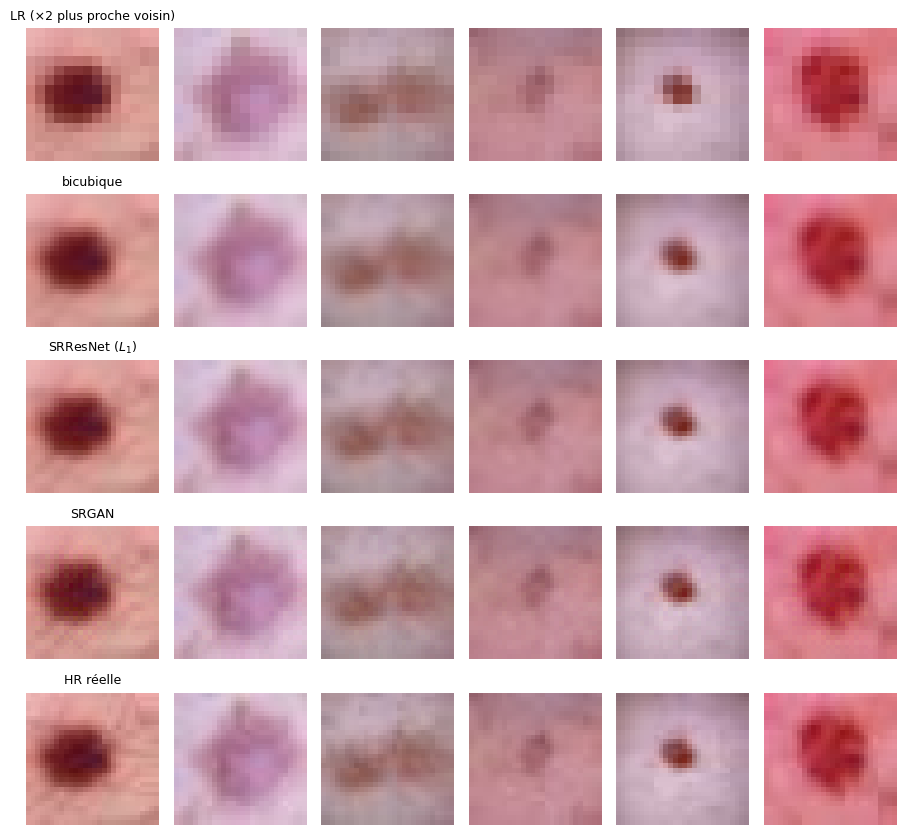

méthode            PSNR (dB)      SSIM
bicubique              37.18     0.972
SRResNet (L1)          38.69     0.979
SRGAN                  36.99     0.969


In [21]:
# --- Comparaison : LR / bicubique / SRResNet (L1) / SRGAN / HR ---
G_sr.eval(); G_srgan.eval()
x6, lr6 = x_val[:6], lr_val[:6]
with torch.no_grad():
    rows = [
        (F.interpolate(lr6, scale_factor=SCALE, mode="nearest"), "LR (×2 plus proche voisin)"),
        (F.interpolate(lr6, scale_factor=SCALE, mode="bicubic").clamp(-1, 1), "bicubique"),
        (G_sr(lr6),    "SRResNet ($L_1$)"),
        (G_srgan(lr6), "SRGAN"),
        (x6,           "HR réelle"),
    ]
imgs, titles = [], []
for batch, lab in rows:
    for j in range(6):
        imgs.append(to01(batch[j].cpu()))
        titles.append(lab if j == 0 else "")
show_grid(imgs, titles=titles, nrow=6)

# --- PSNR / SSIM moyens sur les 512 premières images de test ---
metrics = {m: {"psnr": [], "ssim": []} for m in ["bicubique", "SRResNet (L1)", "SRGAN"]}
n_done = 0
with torch.no_grad():
    for x, _ in test_loader:
        x    = x.to(device).contiguous()
        lr_b = make_lr(x)
        outs = {"bicubique":     F.interpolate(lr_b, scale_factor=SCALE, mode="bicubic").clamp(-1, 1),
                "SRResNet (L1)": G_sr(lr_b),
                "SRGAN":         G_srgan(lr_b)}
        for name, o in outs.items():
            metrics[name]["psnr"].append(psnr(o, x))
            metrics[name]["ssim"].append(ssim_batch(o, x))
        n_done += len(x)
        if n_done >= 512:
            break

print(f"{'méthode':<16}{'PSNR (dB)':>12}{'SSIM':>10}")
for name, m in metrics.items():
    print(f"{name:<16}{np.mean(m['psnr']):>12.2f}{np.mean(m['ssim']):>10.3f}")
# Lecture attendue : SRResNet domine le PSNR (il optimise la distorsion, et son
# résidu global garantit ≥ bicubique) ; SRGAN sacrifie un peu de PSNR pour la
# netteté perçue — c'est le compromis perception-distorsion.

**Quelle métrique pour quel modèle génératif ? (rappel du cours).** Le slide « métriques » distingue deux familles. Ici la super-résolution et la colorisation produisent une sortie **appariée** à une référence : on mesure donc la **fidélité** par le **PSNR** ($10\log_{10}(\mathrm{MAX}^2/\mathrm{MSE})$, en dB, *plus haut = mieux*) et le **SSIM** (produit luminance × contraste × structure, plus proche du jugement de l'œil que le PSNR).

Pour un générateur **sans référence** (DCGAN, cGAN, WGAN-GP : on échantillonne une *distribution*, il n'y a pas d'image « vraie » correspondante), ces métriques n'ont plus de sens. On évalue alors la **distribution générée** par le **FID** — distance entre les *features* Inception-v3 des images réelles et générées, sensible à la qualité **et** à la diversité, si bien que le **mode collapse fait exploser le FID** — ou, historiquement, l'**IS** (*Inception Score*). Le FID demande ≳ 10k images : il n'est pas calculé dans ce TP, mais c'est l'outil de référence pour les Parties III–V (outillage : `pytorch-fid`, `torchmetrics.image.fid`).

## Partie VIII — Situer les GAN : VAE vs GAN vs Diffusion

Ce TP ferme le panorama génératif ouvert au Module 3 :

| | VAE (TP 08) | **GAN (TP 10)** | Diffusion (TP 09) |
|---|---|---|---|
| Principe | maximiser l'ELBO | jeu minimax $G$ vs $D$ | régression de débruitage |
| Densité $p_\theta(\mathbf{x})$ | approchée (borne) | **implicite** (aucune) | approchée (borne) |
| Échantillonnage | 1 passe décodeur | **1 passe** $G$ | $T$ (DDPM) / $S$ (DDIM) passes |
| Rendu | flou (moyenne) | **net** (hautes fréquences) | état de l'art |
| Couverture des modes | bonne | ⚠️ mode collapse possible | excellente |
| Stabilité d'entraînement | stable (une loss) | ⚠️ équilibre de Nash | stable (MSE) |
| Latent structuré | oui ($\mathcal{N}$, interpolable) | oui (interpolable, Partie III) | non (trajectoire de bruit) |

En pratique : la **diffusion** domine la génération pure en qualité/diversité, mais paie ses $S$ passes réseau ; les **GAN** restent le choix quand la **latence d'inférence** compte (super-résolution temps réel, traduction d'image embarquée, augmentation massive) et comme **brique adversariale** dans des systèmes hybrides — la loss perceptuelle + adversariale de SRGAN se greffe d'ailleurs sur n'importe quel modèle de restauration, et la distillation adversariale sert aujourd'hui à compresser les modèles de diffusion vers 1–4 pas.

## Partie IX — Sauvegarde des modèles

Convention du dépôt : `<arch>_<dataset>_best.pt` dans `./checkpoints/`. On ne sauvegarde que les **générateurs** (les discriminateurs/critiques sont des artefacts d'entraînement).

In [22]:
def save_ckpt(model, name, extra=None):
    payload = {"model_state_dict": model.state_dict()}
    if extra:
        payload.update(extra)
    path = CKPT_DIR / name
    torch.save(payload, path)
    print(f"✓ {path}  ({path.stat().st_size/1e6:.1f} Mo)")

save_ckpt(G_dc,    "dcgan_dermamnist_best.pt",    {"z_dim": Z_DIM, "img_size": IMG_SIZE})
save_ckpt(G_c,     "cgan_dermamnist_best.pt",     {"z_dim": Z_DIM, "n_classes": NUM_CLASSES})
save_ckpt(G_w,     "wgangp_dermamnist_best.pt",   {"z_dim": Z_DIM})
save_ckpt(G_p2p,   "pix2pix_dermamnist_best.pt",  {"task": "colorisation Y -> RGB"})
save_ckpt(G_sr,    "srresnet_dermamnist_best.pt", {"scale": SCALE})
save_ckpt(G_srgan, "srgan_dermamnist_best.pt",    {"scale": SCALE})

✓ checkpoints/dcgan_dermamnist_best.pt  (7.7 Mo)
✓ checkpoints/cgan_dermamnist_best.pt  (9.3 Mo)
✓ checkpoints/wgangp_dermamnist_best.pt  (7.7 Mo)
✓ checkpoints/pix2pix_dermamnist_best.pt  (4.5 Mo)
✓ checkpoints/srresnet_dermamnist_best.pt  (2.0 Mo)
✓ checkpoints/srgan_dermamnist_best.pt  (2.0 Mo)


## Partie X — Exercices d'application

### Exercice 1 — Label smoothing unilatéral
Dans `train_gan`, passez la cible réelle de $1{,}0$ à $0{,}9$ (paramètre `label_real`) et réentraînez le DCGAN. Comparez les courbes $D(\mathbf{x})$ / $D(G(\mathbf{z}))$ et les grilles : pourquoi adoucir **uniquement** la cible réelle empêche-t-il $D$ d'écraser le jeu ? Que se passerait-il en adoucissant aussi la cible fausse (réfléchir à $D^*$, I.2) ?

### Exercice 2 — Slerp & arithmétique latente
En grande dimension, $\|\mathbf{z}\| \approx \sqrt{d}$ : la lerp de la Partie III traverse des zones de norme anormalement faible. Implémentez la **slerp** $\text{slerp}(\mathbf{z}_1, \mathbf{z}_2; \alpha) = \frac{\sin((1-\alpha)\Omega)}{\sin\Omega}\,\mathbf{z}_1 + \frac{\sin(\alpha\Omega)}{\sin\Omega}\,\mathbf{z}_2$ (avec $\cos\Omega = \frac{\langle\mathbf{z}_1, \mathbf{z}_2\rangle}{\|\mathbf{z}_1\|\|\mathbf{z}_2\|}$) et comparez visuellement. Puis testez l'**arithmétique latente** : moyennez les $\mathbf{z}$ de 8 images générées sombres et de 8 claires, et visualisez $G(\mathbf{z} + \bar{\mathbf{z}}_{\text{sombre}} - \bar{\mathbf{z}}_{\text{clair}})$.

### Exercice 3 — Provoquer (et mesurer) le mode collapse
Déséquilibrez le jeu : 3 étapes de $G$ par étape de $D$, ou `lr` de $G$ à $10^{-3}$. Mesurez la **diversité** par la distance $L_2$ moyenne entre paires d'un batch généré, $\mathbb{E}\,\|G(\mathbf{z}_i) - G(\mathbf{z}_j)\|$, au fil des epochs — comparée au DCGAN de référence et à un batch réel. Le collapse se voit-il sur les courbes de loss ?

### Exercice 4 — Ablations WGAN-GP
(a) $\lambda = 0$ (aucune contrainte de Lipschitz) : que devient $\widehat{W}$ ? (b) $n_{\text{critic}} = 1$ : $\widehat{W}$ reste-t-elle un indicateur fiable ? (c) Remplacez la GP par le **weight clipping** du WGAN original (`p.data.clamp_(-0.01, 0.01)` après chaque étape de critique) et comparez — pourquoi la GP a-t-elle remplacé le clipping ?

### Exercice 5 — cGAN comme augmentation de données
Générez 500 images de chaque classe rare (*df*, *vasc*) avec le cGAN, ajoutez-les au train du SmallVGG du TP 03 et comparez le **macro-F1** test avant/après ; comparez aussi à l'oversampling par simple duplication. La qualité limitée du cGAN sur ces classes (Partie IV) plafonne-t-elle le gain ?

### Exercice 6 — Le rôle de $\lambda$ dans Pix2Pix
Réentraînez la colorisation avec $\lambda \in \{0, 10, 100\}$. Pour chaque valeur : $L_1$ test + inspection visuelle. À $\lambda = 0$, la couleur est-elle **fidèle** à la cible ou seulement *plausible* (et pourquoi est-ce attendu — qu'optimise un GAN conditionnel sans terme de reconstruction ?) ? À $\lambda = 100$, que reste-t-il à l'adversarial ?

### Exercice 7 — SRGAN ×4 et compromis perception–distorsion
Passez en ×4 (LR $7{\times}7$ → HR $28{\times}28$) en empilant **deux** étages `Conv → PixelShuffle(2) → PReLU`. Comparez bicubique / SRResNet / SRGAN avec PSNR, SSIM **et** une mesure de netteté : la variance du Laplacien (`F.conv2d` avec le noyau $\begin{pmatrix}0&1&0\\1&-4&1\\0&1&0\end{pmatrix}$). Tracez netteté vs PSNR pour matérialiser le compromis perception–distorsion.

---

## Synthèse — API PyTorch des GAN

| Concept | API PyTorch |
|---------|-------------|
| Loss adversariale (logits) | `nn.BCEWithLogitsLoss()` ; cibles `torch.ones_like` / `torch.zeros_like` |
| Étape $D$ sans toucher $G$ | `D(fake.detach())` ; deux optimiseurs séparés |
| Loss non saturante de $G$ | `bce(D(G(z)), torch.ones_like(out))` |
| Upsampling appris | `nn.ConvTranspose2d(ci, co, 4, stride=2, padding=1)` |
| Sub-pixel convolution | `nn.Conv2d(c, c*r**2, 3, 1, 1)` + `nn.PixelShuffle(r)` |
| Init DCGAN | `nn.init.normal_(m.weight, 0.0, 0.02)` |
| Adam « GAN » | `torch.optim.Adam(p, lr=2e-4, betas=(0.5, 0.999))` |
| Conditionnement (cGAN) | `nn.Embedding(n_classes, d)` — concaténé à $\mathbf{z}$ / en carte spatiale |
| Critique Wasserstein | sortie **sans sigmoïde** ; `(D(fake) - D(real)).mean()` |
| Gradient penalty | `torch.autograd.grad(D(x_hat).sum(), x_hat, create_graph=True)[0]` |
| PatchGAN | sortie carte de logits `(B, 1, h, w)` — BCE moyennée sur les patchs |
| Terme $L_1$ (Pix2Pix) | `F.l1_loss(fake, real)`, pondéré $\lambda = 100$ |
| Loss perceptuelle | features d'un réseau **gelé** (`requires_grad_(False)`) + `F.mse_loss` |

---

*Fin du TP 10 — premier TP du **Module 4**.* **TP 11** : *Vision Transformers — ViT, Swin & SegFormer (patch embedding, attention multi-têtes, fine-tuning `timm` / Hugging Face)*.